In [14]:
!pip install selenium pandas beautifulsoup4 lxml webdriver-manager

In [15]:
import selenium
import pandas as pd
from bs4 import BeautifulSoup

print("Selenium:", selenium.__version__)
print("Pandas:", pd.__version__)
print("Libraries installed successfully!")

Selenium: 4.47.0
Pandas: 2.2.2
Libraries installed successfully!


In [16]:
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt-get update -qq
!apt-get install -y ./google-chrome-stable_current_amd64.deb

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'google-chrome-stable' instead of './google-chrome-stable_current_amd64.deb'
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libatk-bridge2.0-0 libatk1.0-0
  libatk1.0-data libatspi2.0-0 libvulkan1 libxcomposite1 libxtst6
  mesa-vulkan-drivers session-migration
The following NEW packages will be installed:
  at-spi2-core google-chrome-stable gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0 libvulkan1
  libxcomposite1 libxtst6 mesa-vulkan-drivers session-migration
0 upgraded, 12 newly installed, 0 to remove and 24 not upgraded.
Need to get 11.2 MB/151 MB of archives.
After this operation, 505 MB of addition

In [17]:
!google-chrome --version

Google Chrome 151.0.7922.137 


In [18]:
!which google-chrome
!google-chrome --version
!which chromedriver
!chromedriver --version

/usr/bin/google-chrome
Google Chrome 151.0.7922.137 
/bin/bash: line 1: chromedriver: command not found


In [19]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options

options = Options()

options.binary_location = "/usr/bin/google-chrome"

options.add_argument("--headless=new")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--disable-gpu")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(options=options)

print("✅ Selenium + Chrome working!")
print("Browser:", driver.capabilities["browserName"])
print("Chrome:", driver.capabilities["browserVersion"])

✅ Selenium + Chrome working!
Browser: chrome
Chrome: 151.0.7922.137


In [20]:
driver.get("https://www.google.com")

print("Title:", driver.title)
print("URL:", driver.current_url)

Title: Google
URL: https://www.google.com/


In [21]:
trustpilot_url = "https://www.trustpilot.com/review/ubereats.com"

driver.get(trustpilot_url)

print("Title:", driver.title)
print("URL:", driver.current_url)
print("Page source length:", len(driver.page_source))

Title: Verifying Connection
URL: https://www.trustpilot.com/review/ubereats.com
Page source length: 1046


In [22]:
page_text = driver.find_element("tag name", "body").text

print(page_text[:3000])

Verifying your connection...
Verified! Redirecting...


In [23]:
print("Final URL:", driver.current_url)
print("Title:", driver.title)

if "trustpilot" in driver.current_url.lower():
    print("✅ We are on a Trustpilot page")
else:
    print("⚠️ We were redirected somewhere else")

Final URL: https://www.trustpilot.com/review/ubereats.com
Title: Verifying Connection
✅ We are on a Trustpilot page


**Step 1E — Inspect the review elements**

In [24]:
from selenium.webdriver.common.by import By

reviews = driver.find_elements(By.CSS_SELECTOR, '[data-review-id]')

print("Reviews found:", len(reviews))

Reviews found: 0


In [25]:
elements = driver.find_elements(By.CSS_SELECTOR, 'article')

print("Article elements:", len(elements))

for i, element in enumerate(elements[:10]):
    print("\n--- ARTICLE", i, "---")
    print(element.text[:1000])

Article elements: 0


In [26]:
review_text = "I’m honestly tired"

elements = driver.find_elements(
    By.XPATH,
    f"//*[contains(text(), '{review_text}')]"
)

print("Matching elements:", len(elements))

for element in elements:
    print("TAG:", element.tag_name)
    print("CLASS:", element.get_attribute("class"))
    print("TEXT:", element.text[:500])

Matching elements: 0


In [27]:
articles = driver.find_elements(By.TAG_NAME, "article")

**Step 1F — Inspect Article 6**

In [29]:
article = driver.find_elements(By.TAG_NAME, "article")[6]

print(article.get_attribute("outerHTML"))

<article class="CDS_Card_card__146e7a styles_reviewCard__Qwhpy" data-service-review-card-paper="true"><div data-testid="service-review-card-v2"><div class="styles_reviewCardInnerHeader__8Xqy8"><aside class="styles_consumerInfoWrapper__6HN5O" aria-label="Info for J Bella"><div class="styles_consumerDetailsWrapper__4eZod"><div class="CDS_Avatar_avatar__375238 CDS_Avatar_orange__375238" style="width:44px;min-width:44px;height:44px;min-height:44px" data-testid="consumer-avatar"><span class="CDS_Typography_appearance-default__da5bc0 CDS_Typography_prettyStyle__da5bc0 CDS_Typography_heading-xs__da5bc0 CDS_Typography_disableResponsiveSizing__da5bc0 CDS_Avatar_avatarName__375238">JB</span></div><a data-cpl="true" href="/users/63363a5a5a9ecb00128b8999" rel="nofollow" name="consumer-profile" target="_self" class="link_internal__Eam_b link_wrapper__ahpyq styles_consumerDetails__POC79" data-consumer-profile-link="true"><span class="CDS_Typography_appearance-default__da5bc0 CDS_Typography_prettySty

In [30]:
# Get all elements inside Article 6
children = article.find_elements(By.XPATH, ".//*")

print("Total child elements:", len(children))

for i, element in enumerate(children):
    text = element.text.strip()

    if text:
        print(
            f"\n[{i}] TAG={element.tag_name}"
            f"\nCLASS={element.get_attribute('class')}"
            f"\nTEXT={text[:300]}"
        )

Total child elements: 40

[0] TAG=div
CLASS=
TEXT=JB
J Bella
US
•
3 reviews
6 hours ago
Uber Eats is a Rip Off
Uber Eats is an absolute rip off. The menu prices are higher than they are in the stores, the service fees are ridiculous that even when you get a 50% off coupon, promotion, you wind up paying the same amount because they up the taxes and 

[1] TAG=div
CLASS=styles_reviewCardInnerHeader__8Xqy8
TEXT=JB
J Bella
US
•
3 reviews
6 hours ago

[2] TAG=aside
CLASS=styles_consumerInfoWrapper__6HN5O
TEXT=JB
J Bella
US
•
3 reviews

[3] TAG=div
CLASS=styles_consumerDetailsWrapper__4eZod
TEXT=JB
J Bella
US
•
3 reviews

[4] TAG=div
CLASS=CDS_Avatar_avatar__375238 CDS_Avatar_orange__375238
TEXT=JB

[5] TAG=span
CLASS=CDS_Typography_appearance-default__da5bc0 CDS_Typography_prettyStyle__da5bc0 CDS_Typography_heading-xs__da5bc0 CDS_Typography_disableResponsiveSizing__da5bc0 CDS_Avatar_avatarName__375238
TEXT=JB

[6] TAG=a
CLASS=link_internal__Eam_b link_wrapper__ahpyq styles_consumerDetails__P

**Step 1G — Inspect links**

In [31]:
links = article.find_elements(By.TAG_NAME, "a")

print("Links:", len(links))

for i, link in enumerate(links):
    print(
        f"\n[{i}]"
        f"\nText: {link.text.strip()}"
        f"\nHref: {link.get_attribute('href')}"
        f"\nClass: {link.get_attribute('class')}"
    )

Links: 2

[0]
Text: J Bella
US
•
3 reviews
Href: https://www.trustpilot.com/users/63363a5a5a9ecb00128b8999
Class: link_internal__Eam_b link_wrapper__ahpyq styles_consumerDetails__POC79

[1]
Text: Uber Eats is a Rip Off
Href: https://www.trustpilot.com/reviews/6a7bce6625e143cdd93f967c
Class: CDS_Typography_appearance-inherit__da5bc0 CDS_Typography_prettyStyle__da5bc0 CDS_Link_link__a59334 CDS_Link_noUnderline__a59334


**Step 1H — Inspect buttons**

In [32]:
buttons = article.find_elements(By.TAG_NAME, "button")

print("Buttons:", len(buttons))

for i, button in enumerate(buttons):
    print(
        f"\n[{i}]"
        f"\nText: {button.text.strip()}"
        f"\nAria-label: {button.get_attribute('aria-label')}"
        f"\nClass: {button.get_attribute('class')}"
    )

Buttons: 3

[0]
Text: Useful
Aria-label: None
Class: CDS_Typography_appearance-subtle__da5bc0 CDS_Typography_prettyStyle__da5bc0 CDS_Link_link__a59334 buttons_actionButtons__SZCAW buttons_button__ECb04 CDS_Link_asButton__a59334 CDS_Link_buttonInherit__a59334 CDS_Link_noUnderline__a59334

[1]
Text: Share
Aria-label: Share
Class: CDS_Typography_appearance-subtle__da5bc0 CDS_Typography_prettyStyle__da5bc0 CDS_Link_link__a59334 buttons_actionButtons__SZCAW buttons_button__ECb04 CDS_Link_asButton__a59334 CDS_Link_buttonInherit__a59334 CDS_Link_noUnderline__a59334

[2]
Text: 
Aria-label: Flag this review
Class: styles_iconButton__Sr5FD


**Step 1I — Build our first extractor**

In [33]:
from selenium.webdriver.common.by import By


def extract_review(article, company, industry):
    """Extract one Trustpilot review from an article element."""

    # Company
    company_name = company

    # Industry
    industry_name = industry

    # Reviewer
    reviewer = article.find_element(
        By.CSS_SELECTOR,
        '[data-consumer-name-typography="true"]'
    ).text.strip()

    # Rating
    rating_element = article.find_element(
        By.CSS_SELECTOR,
        '[data-service-review-rating]'
    )

    rating = int(
        rating_element.get_attribute("data-service-review-rating")
    )

    # Review title
    title_elements = article.find_elements(
        By.CSS_SELECTOR,
        '[data-service-review-title-typography="true"]'
    )

    review_title = (
        title_elements[0].text.strip()
        if title_elements
        else ""
    )

    # Review text
    text_element = article.find_element(
        By.CSS_SELECTOR,
        '[data-service-review-text-typography="true"]'
    )

    review_text = text_element.text.strip()

    # Review date
    date_elements = article.find_elements(
        By.CSS_SELECTOR,
        '[data-testid="review-badge-date"]'
    )

    review_date = (
        date_elements[0].text.strip()
        if date_elements
        else ""
    )

    return {
        "Company": company_name,
        "Industry": industry_name,
        "Review Title": review_title,
        "Review Text": review_text,
        "Rating": rating,
        "Date": review_date,
        "Reviewer": reviewer
    }

**Test it on J Bella**

In [34]:
article = driver.find_elements(By.TAG_NAME, "article")[6]

In [35]:
review = extract_review(
    article,
    company="Uber Eats",
    industry="Food Delivery"
)

review

{'Company': 'Uber Eats',
 'Industry': 'Food Delivery',
 'Review Title': 'Uber Eats is a Rip Off',
 'Review Text': 'Uber Eats is an absolute rip off. The menu prices are higher than they are in the stores, the service fees are ridiculous that even when you get a 50% off coupon, promotion, you wind up paying the same amount because they up the taxes and service fee. They have crappy drivers that deliver food haphazard lay and yes, while they will give you a refund from time to time you have to go and spend another 30 to 45 minutes taking pictures of the food and talking with the customer service rep and there goes your whole ordering out to have an easy night option. Uber Eats is a rip off and they don’t have high standards when it comes to delivery drivers.',
 'Rating': 1,
 'Date': 'August 6, 2026',
 'Reviewer': 'J Bella'}

**Step 1J — Extract all currently loaded reviews**

In [36]:
articles = driver.find_elements(By.TAG_NAME, "article")

reviews = []

for article in articles:

    try:
        review = extract_review(
            article,
            company="Uber Eats",
            industry="Food Delivery"
        )

        reviews.append(review)

    except Exception as e:
        print("Skipped an article:", type(e).__name__)

Skipped an article: NoSuchElementException
Skipped an article: NoSuchElementException
Skipped an article: NoSuchElementException
Skipped an article: NoSuchElementException


In [37]:
print("Reviews extracted:", len(reviews))

Reviews extracted: 20


In [38]:
import pandas as pd

df = pd.DataFrame(reviews)

df

,Company,Industry,Review Title,Review Text,Rating,Date,Reviewer
0,Uber Eats,Food Delivery,One star is extremely generous for a…,One star is extremely generous for a company t...,1,"August 11, 2026",RVA LYFE
1,Uber Eats,Food Delivery,I WISH YOU COULD LEAVE A NEGATIVE…,I WISH YOU COULD LEAVE A NEGATIVE RATING. THIS...,1,"July 30, 2026",Randy Marsh
2,Uber Eats,Food Delivery,Uber Eats is a Rip Off,Uber Eats is an absolute rip off. The menu pri...,1,"August 6, 2026",J Bella
3,Uber Eats,Food Delivery,A Mystery $37 extra... and a Wannabe ai Bot.,I had some negative experiences in the past wi...,1,"August 11, 2026",Kirk
4,Uber Eats,Food Delivery,This got to be the worst company that…,This got to be the worst company that you can ...,1,"August 2, 2026",LR Brown
5,Uber Eats,Food Delivery,The delivery guy did not deliver my…,"The delivery guy did not deliver my food , he ...",1,"August 11, 2026",sbusisiwekheswagmail.com
6,Uber Eats,Food Delivery,Still battling an non order of main…,Still battling an non order of main food( no d...,1,"May 14, 2026",Susan Farrell
7,Uber Eats,Food Delivery,Costumer service is very bad,Costumer service is very bad. I was promised i...,1,"June 26, 2026",Patricio Rodriguez
8,Uber Eats,Food Delivery,"Uber Eats, improving fast",I've spent a lot of time being annoyed at Uber...,4,"August 10, 2026",JOSEPH MARTIN
9,Uber Eats,Food Delivery,Delivered wthin their 'latest estimates' which...,"Uber kept pushing the delivery time later, the...",1,"August 10, 2026",Jimmy


**Step 1K — Check the dataset**

In [39]:
print(df.shape)
print()
print(df.columns.tolist())

(20, 7)

['Company', 'Industry', 'Review Title', 'Review Text', 'Rating', 'Date', 'Reviewer']


In [40]:
df.head()

,Company,Industry,Review Title,Review Text,Rating,Date,Reviewer
0,Uber Eats,Food Delivery,One star is extremely generous for a…,One star is extremely generous for a company t...,1,"August 11, 2026",RVA LYFE
1,Uber Eats,Food Delivery,I WISH YOU COULD LEAVE A NEGATIVE…,I WISH YOU COULD LEAVE A NEGATIVE RATING. THIS...,1,"July 30, 2026",Randy Marsh
2,Uber Eats,Food Delivery,Uber Eats is a Rip Off,Uber Eats is an absolute rip off. The menu pri...,1,"August 6, 2026",J Bella
3,Uber Eats,Food Delivery,A Mystery $37 extra... and a Wannabe ai Bot.,I had some negative experiences in the past wi...,1,"August 11, 2026",Kirk
4,Uber Eats,Food Delivery,This got to be the worst company that…,This got to be the worst company that you can ...,1,"August 2, 2026",LR Brown


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Company       20 non-null     object
 1   Industry      20 non-null     object
 2   Review Title  20 non-null     object
 3   Review Text   20 non-null     object
 4   Rating        20 non-null     int64 
 5   Date          20 non-null     object
 6   Reviewer      20 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.2+ KB


In [42]:
print(df["Rating"].value_counts().sort_index())

Rating
1    19
4     1
Name: count, dtype: int64


In [43]:
df = df[
    [
        "Company",
        "Industry",
        "Review Title",
        "Review Text",
        "Rating",
        "Date"
    ]
]

In [44]:
print(df.isnull().sum())

Company         0
Industry        0
Review Title    0
Review Text     0
Rating          0
Date            0
dtype: int64


In [45]:
print("Duplicate reviews:", df["Review Text"].duplicated().sum())

Duplicate reviews: 0


In [46]:
print("Empty titles:", (df["Review Title"].fillna("").str.strip() == "").sum())
print("Empty texts:", (df["Review Text"].fillna("").str.strip() == "").sum())

Empty titles: 0
Empty texts: 0


In [47]:
df.to_csv("trustpilot_ubereats_test.csv", index=False)

print("Saved:", len(df), "reviews")

Saved: 20 reviews


**Step 1L — Scroll down and check**

In [48]:
from selenium.webdriver.common.by import By
import time

print("Before scrolling:", len(driver.find_elements(By.TAG_NAME, "article")))

driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")

time.sleep(3)

print("After scrolling:", len(driver.find_elements(By.TAG_NAME, "article")))

Before scrolling: 24
After scrolling: 24


In [49]:
driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")

time.sleep(3)

print("After second scroll:", len(driver.find_elements(By.TAG_NAME, "article")))

After second scroll: 24


**Step 1M — Look for pagination controls**

In [51]:
from selenium.webdriver.common.by import By

# Look for links/buttons containing pagination-related text
elements = driver.find_elements(
    By.XPATH,
    "//a | //button"
)

for element in elements:
    text = element.text.strip()
    aria = element.get_attribute("aria-label")

    if text or aria:
        combined = f"{text} {aria or ''}".lower()

        if any(word in combined for word in [
            "next", "page", "more", "reviews"
        ]):
            print(
                "TAG:", element.tag_name,
                "| TEXT:", text,
                "| ARIA:", aria,
                "| HREF:", element.get_attribute("href")
            )

TAG: button | TEXT: Reviews | ARIA: None | HREF: None
TAG: button | TEXT: We use technology to protect platform integrity, but we don't fact-check reviews | ARIA: None | HREF: None
TAG: button | TEXT: See more | ARIA: None | HREF: None
TAG: button | TEXT: See all 116,143 reviews | ARIA: None | HREF: None
TAG: button | TEXT: Hasn’t replied to negative reviews
May use AI-assist with replies | ARIA: None | HREF: None
TAG: a | TEXT: How this company uses Trustpilot
See how their reviews and ratings are sourced, scored, and moderated. | ARIA: None | HREF: https://www.trustpilot.com/review/ubereats.com/transparency
TAG: a | TEXT: How Trustpilot labels reviews | ARIA: None | HREF: https://help.trustpilot.com/s/article/About-Trustpilots-review-labels?language=en_US
TAG: a | TEXT: Read more | ARIA: None | HREF: https://help.trustpilot.com/s/article/How-do-we-make-sure-reviews-are-trustworthy?language=en_US
TAG: button | TEXT: More filters | ARIA: None | HREF: None
TAG: a | TEXT: Randy Marsh
AU


In [52]:
driver.execute_script(
    "window.scrollTo(0, document.body.scrollHeight);"
)

time.sleep(2)

print(driver.find_element(By.TAG_NAME, "body").text[-3000:])

e the delivery guy called (and i didn't answer straight away) i cant get a refund. I hope someone at least enjoyed the meal, whom ever found it
July 30, 2026
Unprompted review
Useful
Share
Tegan Carnell
GB
•
1 review
2 days ago
If I could rate less I would
If I could rate less I would , ordered smoothies . Spent £40 worth and the rider dropped them all over my doorstep. He insisted they’d refund me and they just won’t even when I have photographic and audio evidence from cctv. Ridiculous
August 2, 2026
Unprompted review
Useful
Share
UN
Unknown
GB
•
16 reviews
2 days ago
nigligent deliveries
ordered food and the del;ivery driver sat in the car park for 15 minutes before i text him to ask why he then started to move, when i recieved the food over 20 mins later it was cold, customer services accept this as acceptible with no resolution otherv than close the chat
August 10, 2026
Unprompted review
Useful
Share
Khurrum
GB
•
23 reviews
2 days ago
Terrible disgusting customer services avoid
I 

**Step 1N — Find the "Next page" element**

In [53]:
next_elements = driver.find_elements(
    By.XPATH,
    "//a[contains(translate(normalize-space(.), 'ABCDEFGHIJKLMNOPQRSTUVWXYZ', 'abcdefghijklmnopqrstuvwxyz'), 'next')]"
    " | "
    "//button[contains(translate(normalize-space(.), 'ABCDEFGHIJKLMNOPQRSTUVWXYZ', 'abcdefghijklmnopqrstuvwxyz'), 'next')]"
)

print("Next elements found:", len(next_elements))

for i, element in enumerate(next_elements):
    print("\n---", i, "---")
    print("Tag:", element.tag_name)
    print("Text:", element.text)
    print("Aria:", element.get_attribute("aria-label"))
    print("Href:", element.get_attribute("href"))
    print("Class:", element.get_attribute("class"))

Next elements found: 1

--- 0 ---
Tag: a
Text: Next page
Aria: Next page
Href: https://www.trustpilot.com/review/ubereats.com?page=2
Class: link_internal__Eam_b button_button__EM6gX button_m__J8iy5 button_appearance-outline__K_fYw button_squared__ApvnR link_button__5LH_w pagination-link_buttonItem__BQ0JJ pagination-link_next__NdSsd


**Step 1O — Inspect the numbered pages**

In [54]:
page_links = driver.find_elements(
    By.XPATH,
    "//a[normalize-space(text())='2' or normalize-space(text())='3' or normalize-space(text())='4']"
)

print("Numbered page links:", len(page_links))

for element in page_links:
    print(
        "Text:", element.text,
        "| Href:", element.get_attribute("href"),
        "| Class:", element.get_attribute("class")
    )

Numbered page links: 0


**Step 1P — Test Page 2 manually**

In [55]:
page_2_url = "https://www.trustpilot.com/review/ubereats.com?page=2"

driver.get(page_2_url)

time.sleep(3)

print("Current URL:", driver.current_url)
print("Title:", driver.title)
print("Articles:", len(driver.find_elements(By.TAG_NAME, "article")))

Current URL: https://www.trustpilot.com/review/ubereats.com?page=2
Title: UberEATS Reviews | Read Customer Service Reviews of ubereats.com | 2 of 3,834
Articles: 24


In [56]:
articles_page2 = driver.find_elements(By.TAG_NAME, "article")

page2_reviews = []

for article in articles_page2:
    try:
        review = extract_review(
            article,
            company="Uber Eats",
            industry="Food Delivery"
        )

        page2_reviews.append(review)

    except Exception:
        pass

print("Page 2 reviews extracted:", len(page2_reviews))

Page 2 reviews extracted: 20


In [57]:
pd.DataFrame(page2_reviews).head()

,Company,Industry,Review Title,Review Text,Rating,Date,Reviewer
0,Uber Eats,Food Delivery,Uber eats is stealing money from us by…,Uber eats is stealing money from us by not ref...,1,"August 10, 2026",Moritikei Tuikadavu Railoa
1,Uber Eats,Food Delivery,I placed an order with our local Tim…,I placed an order with our local Tim Hortons. ...,1,"August 9, 2026",customer
2,Uber Eats,Food Delivery,Would not use Pizza Hut in Oxford Road…,Would not use Pizza Hut in Oxford Road Reading...,1,"August 10, 2026",Thomas
3,Uber Eats,Food Delivery,Tired of service fees your order can be…,Tired of service fees your order can be 37 but...,1,"August 9, 2026",Agnes Whitehurst
4,Uber Eats,Food Delivery,The order was delivered wrong,The order was delivered completely wrong and t...,1,"August 9, 2026",Ariel Welton


**Step 2 — Build the multi-page scraper**

In [58]:
import time
import pandas as pd
from selenium.webdriver.common.by import By


def scrape_trustpilot(
    start_url,
    company,
    industry,
    target_reviews=500,
    delay=2
):

    all_reviews = []
    visited_urls = set()

    current_url = start_url
    page_number = 1

    while len(all_reviews) < target_reviews:

        # Prevent accidental loops
        if current_url in visited_urls:
            print("Already visited this page. Stopping.")
            break

        visited_urls.add(current_url)

        print(f"\n{'=' * 50}")
        print(f"Page {page_number}")
        print(f"URL: {current_url}")
        print(f"{'=' * 50}")

        # Open page
        driver.get(current_url)

        # Give JavaScript time to render
        time.sleep(delay)

        # Find review cards
        articles = driver.find_elements(
            By.TAG_NAME,
            "article"
        )

        print("Articles found:", len(articles))

        page_count = 0

        # Extract reviews
        for article in articles:

            if len(all_reviews) >= target_reviews:
                break

            try:

                review = extract_review(
                    article,
                    company=company,
                    industry=industry
                )

                # Basic validation
                if not review["Review Text"]:
                    continue

                all_reviews.append(review)
                page_count += 1

            except Exception as e:
                continue

        print("Reviews extracted from page:", page_count)
        print("Total reviews:", len(all_reviews))

        # Stop if target reached
        if len(all_reviews) >= target_reviews:
            print("\n🎯 Target reached!")
            break

        # Find Next page
        next_elements = driver.find_elements(
            By.XPATH,
            "//a[@aria-label='Next page']"
        )

        if not next_elements:
            print("\nNo more pages found.")
            break

        next_url = next_elements[0].get_attribute("href")

        if not next_url:
            print("\nNext page has no URL. Stopping.")
            break

        current_url = next_url
        page_number += 1

    return pd.DataFrame(all_reviews)

**Step 2A — Test with only 60 reviews**

In [59]:
df_60 = scrape_trustpilot(
    start_url="https://www.trustpilot.com/review/ubereats.com",
    company="Uber Eats",
    industry="Food Delivery",
    target_reviews=60,
    delay=2
)


Page 1
URL: https://www.trustpilot.com/review/ubereats.com
Articles found: 24
Reviews extracted from page: 20
Total reviews: 20

Page 2
URL: https://www.trustpilot.com/review/ubereats.com?page=2
Articles found: 24
Reviews extracted from page: 20
Total reviews: 40

Page 3
URL: https://www.trustpilot.com/review/ubereats.com?page=3
Articles found: 24
Reviews extracted from page: 20
Total reviews: 60

🎯 Target reached!


In [60]:
print("\nFinal shape:", df_60.shape)


Final shape: (60, 7)


In [61]:
df_60.head()

,Company,Industry,Review Title,Review Text,Rating,Date,Reviewer
0,Uber Eats,Food Delivery,One star is extremely generous for a…,One star is extremely generous for a company t...,1,"August 11, 2026",RVA LYFE
1,Uber Eats,Food Delivery,I WISH YOU COULD LEAVE A NEGATIVE…,I WISH YOU COULD LEAVE A NEGATIVE RATING. THIS...,1,"July 30, 2026",Randy Marsh
2,Uber Eats,Food Delivery,Uber Eats is a Rip Off,Uber Eats is an absolute rip off. The menu pri...,1,"August 6, 2026",J Bella
3,Uber Eats,Food Delivery,A Mystery $37 extra... and a Wannabe ai Bot.,I had some negative experiences in the past wi...,1,"August 11, 2026",Kirk
4,Uber Eats,Food Delivery,This got to be the worst company that…,This got to be the worst company that you can ...,1,"August 2, 2026",LR Brown


In [62]:
print(df_60["Rating"].value_counts().sort_index())

Rating
1    58
2     1
4     1
Name: count, dtype: int64


**Step 3 — Make the scraper production-ready**

In [63]:
def extract_review(article, company, industry):
    """Extract one Trustpilot review."""

    # Review ID / URL
    review_links = article.find_elements(
        By.CSS_SELECTOR,
        'a[data-review-title-typography="true"]'
    )

    review_id = ""

    if review_links:
        href = review_links[0].get_attribute("href")

        if href:
            review_id = href.rstrip("/").split("/")[-1]

    # Reviewer
    reviewer_elements = article.find_elements(
        By.CSS_SELECTOR,
        '[data-consumer-name-typography="true"]'
    )

    reviewer = (
        reviewer_elements[0].text.strip()
        if reviewer_elements
        else ""
    )

    # Rating
    rating_elements = article.find_elements(
        By.CSS_SELECTOR,
        '[data-service-review-rating]'
    )

    rating = None

    if rating_elements:
        rating = int(
            rating_elements[0].get_attribute(
                "data-service-review-rating"
            )
        )

    # Review title
    title_elements = article.find_elements(
        By.CSS_SELECTOR,
        '[data-service-review-title-typography="true"]'
    )

    review_title = (
        title_elements[0].text.strip()
        if title_elements
        else ""
    )

    # Review text
    text_elements = article.find_elements(
        By.CSS_SELECTOR,
        '[data-service-review-text-typography="true"]'
    )

    review_text = (
        text_elements[0].text.strip()
        if text_elements
        else ""
    )

    # Date
    date_elements = article.find_elements(
        By.CSS_SELECTOR,
        '[data-testid="review-badge-date"]'
    )

    review_date = (
        date_elements[0].text.strip()
        if date_elements
        else ""
    )

    return {
        "Review_ID": review_id,
        "Company": company,
        "Industry": industry,
        "Review Title": review_title,
        "Review Text": review_text,
        "Rating": rating,
        "Date": review_date,
        "Reviewer": reviewer
    }

In [64]:
seen_ids = set()

In [65]:
test_article = driver.find_elements(By.TAG_NAME, "article")[0]

test_review = extract_review(
    test_article,
    "Uber Eats",
    "Food Delivery"
)

test_review

{'Review_ID': '',
 'Company': 'Uber Eats',
 'Industry': 'Food Delivery',
 'Review Title': '',
 'Review Text': '',
 'Rating': None,
 'Date': '',
 'Reviewer': 'Layla'}

In [66]:
test_article = driver.find_elements(By.TAG_NAME, "article")[6]

test_review = extract_review(
    test_article,
    "Uber Eats",
    "Food Delivery"
)

test_review

{'Review_ID': '6a7771b7a5f6f3b34a66e4d5',
 'Company': 'Uber Eats',
 'Industry': 'Food Delivery',
 'Review Title': 'the WORST delivery service',
 'Review Text': 'Uber Eats is one of the worst delivery services out there. As a corporate business, you would think they would take care of their customers, but they do not. I have had instances where my food is running 30-45 mins later than the initial expected time, but they require me to wait up (even if it is a late night at 1-2am) in order to cancel the order. Also, they automatically chose the destination of your food for you, so if you are not at home when ordering your food it will be sent elsewhere. Overall, I do not recommend to anyone, and would suggest to always use Door Dash instead.',
 'Rating': 1,
 'Date': 'August 7, 2026',
 'Reviewer': 'Kasey Klimas'}

**Step 3 — Final 500-review scraper**

In [68]:
def scrape_trustpilot(
    start_url,
    company,
    industry,
    target_reviews=500,
    delay=2
):

    all_reviews = []
    seen_ids = set()
    visited_urls = set()

    current_url = start_url
    page_number = 1

    while len(all_reviews) < target_reviews:

        # Prevent URL loops
        if current_url in visited_urls:
            print("Already visited this page. Stopping.")
            break

        visited_urls.add(current_url)

        print("\n" + "=" * 60)
        print(f"Page {page_number}")
        print(f"URL: {current_url}")
        print("=" * 60)

        # Open page
        driver.get(current_url)

        # Allow JavaScript to render
        time.sleep(delay)

        # Find article elements
        articles = driver.find_elements(
            By.TAG_NAME,
            "article"
        )

        print("Articles found:", len(articles))

        page_count = 0
        skipped = 0
        duplicates = 0

        for article in articles:

            if len(all_reviews) >= target_reviews:
                break

            try:

                review = extract_review(
                    article,
                    company=company,
                    industry=industry
                )

                # Skip incomplete articles
                if not review["Review_ID"]:
                    skipped += 1
                    continue

                if not review["Review Text"]:
                    skipped += 1
                    continue

                if review["Rating"] is None:
                    skipped += 1
                    continue

                # Duplicate protection
                if review["Review_ID"] in seen_ids:
                    duplicates += 1
                    continue

                # Add ID to seen set
                seen_ids.add(review["Review_ID"])

                all_reviews.append(review)
                page_count += 1

            except Exception as e:
                skipped += 1

        print("New reviews:", page_count)
        print("Skipped:", skipped)
        print("Duplicates:", duplicates)
        print("Total collected:", len(all_reviews))

        # Target reached
        if len(all_reviews) >= target_reviews:
            print("\n🎯 Target of 500 reviews reached!")
            break

        # Find Next page
        next_elements = driver.find_elements(
            By.XPATH,
            "//a[@aria-label='Next page']"
        )

        if not next_elements:
            print("\nNo more pages available.")
            break

        next_url = next_elements[0].get_attribute("href")

        if not next_url:
            print("\nNext page has no URL. Stopping.")
            break

        current_url = next_url
        page_number += 1

    # Convert to DataFrame
    df = pd.DataFrame(all_reviews)

    return df

**Step 3A — Collect 500 Uber Eats reviews**

In [69]:
df_ubereats = scrape_trustpilot(
    start_url="https://www.trustpilot.com/review/ubereats.com",
    company="Uber Eats",
    industry="Food Delivery",
    target_reviews=500,
    delay=2
)


Page 1
URL: https://www.trustpilot.com/review/ubereats.com
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 20

Page 2
URL: https://www.trustpilot.com/review/ubereats.com?page=2
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 40

Page 3
URL: https://www.trustpilot.com/review/ubereats.com?page=3
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 60

Page 4
URL: https://www.trustpilot.com/review/ubereats.com?page=4
Articles found: 24
New reviews: 19
Skipped: 5
Duplicates: 0
Total collected: 79

Page 5
URL: https://www.trustpilot.com/review/ubereats.com?page=5
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 99

Page 6
URL: https://www.trustpilot.com/review/ubereats.com?page=6
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 119

Page 7
URL: https://www.trustpilot.com/review/ubereats.com?page=7
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates:

**Step 3B — Validate the 500 reviews**

In [70]:
print("Dataset shape:", df_ubereats.shape)

print(
    "Duplicate Review IDs:",
    df_ubereats["Review_ID"].duplicated().sum()
)

print(
    "Duplicate Review Text:",
    df_ubereats["Review Text"].duplicated().sum()
)

Dataset shape: (199, 8)
Duplicate Review IDs: 0
Duplicate Review Text: 0


In [71]:
print(df_ubereats["Rating"].value_counts().sort_index())

Rating
1    188
2      7
3      2
4      1
5      1
Name: count, dtype: int64


**Step 3C — Remove the internal Review_ID**

In [72]:
final_ubereats = df_ubereats[
    [
        "Company",
        "Industry",
        "Review Title",
        "Review Text",
        "Rating",
        "Date"
    ]
].copy()

In [73]:
final_ubereats.to_csv(
    "Uber_Eats_reviews.csv",
    index=False
)

print(
    "Saved:",
    len(final_ubereats),
    "reviews"
)

Saved: 199 reviews


In [74]:
driver.get(
    "https://www.trustpilot.com/review/ubereats.com?page=11"
)

time.sleep(5)

print("URL:", driver.current_url)
print("Title:", driver.title)
print("Source length:", len(driver.page_source))

print(driver.page_source[:2000])

URL: https://www.trustpilot.com/users/connect?redirect=%2Freview%2Fubereats.com%3Fpage%3D11
Title: Trustpilot Login - Connect and share your reviews
Source length: 509363
<html lang="en-US"><head><meta http-equiv="origin-trial" content="A7vZI3v+Gz7JfuRolKNM4Aff6zaGuT7X0mf3wtoZTnKv6497cVMnhy03KDqX7kBz/q/iidW7srW31oQbBt4VhgoAAACUeyJvcmlnaW4iOiJodHRwczovL3d3dy5nb29nbGUuY29tOjQ0MyIsImZlYXR1cmUiOiJEaXNhYmxlVGhpcmRQYXJ0eVN0b3JhZ2VQYXJ0aXRpb25pbmczIiwiZXhwaXJ5IjoxNzU3OTgwODAwLCJpc1N1YmRvbWFpbiI6dHJ1ZSwiaXNUaGlyZFBhcnR5Ijp0cnVlfQ=="><style type="text/css">.CDS_Card_card__146e7a{background-color:var(--CDS-color-background-neutral-base)}.CDS_Card_card__146e7a,.CDS_Card_card__146e7a :after,.CDS_Card_card__146e7a :before{box-sizing:border-box;margin:0;padding:0}a.CDS_Card_card__146e7a{display:inline-block;text-decoration:none}button.CDS_Card_card__146e7a{cursor:pointer;text-align:start}.CDS_Card_alt__146e7a{background-color:var(--CDS-color-background-neutral-subtle)}.CDS_Card_appearance-default__1

In [75]:
driver.get(
    "https://www.trustpilot.com/review/ubereats.com?page=10"
)

time.sleep(5)

print("Title:", driver.title)
print(
    "Articles:",
    len(driver.find_elements(By.TAG_NAME, "article"))
)

Title: UberEATS Reviews | Read Customer Service Reviews of ubereats.com | 10 of 3,834
Articles: 24


In [77]:
def scrape_trustpilot(
    start_url,
    company,
    industry,
    target_reviews=500,
    delay=2
):

    all_reviews = []
    seen_ids = set()
    visited_urls = set()

    current_url = start_url
    page_number = 1

    while len(all_reviews) < target_reviews:

        # Prevent URL loops
        if current_url in visited_urls:
            print("Already visited this page. Stopping.")
            break

        visited_urls.add(current_url)

        print("\n" + "=" * 60)
        print(f"Page {page_number}")
        print(f"URL: {current_url}")
        print("=" * 60)

        # Open page
        driver.get(current_url)

        # Allow JavaScript to load
        time.sleep(delay)

        # ---------------------------------------
        # CHECK FOR LOGIN REDIRECT
        # ---------------------------------------
        if "/users/connect" in driver.current_url:

            print("\n⚠️ Trustpilot redirected to login.")
            print("Current URL:", driver.current_url)
            print("Stopping scraper safely.")

            break

        # ---------------------------------------
        # FIND REVIEW ARTICLES
        # ---------------------------------------
        articles = driver.find_elements(
            By.TAG_NAME,
            "article"
        )

        print("Articles found:", len(articles))

        page_count = 0
        skipped = 0
        duplicates = 0

        # ---------------------------------------
        # EXTRACT REVIEWS
        # ---------------------------------------
        for article in articles:

            if len(all_reviews) >= target_reviews:
                break

            try:

                review = extract_review(
                    article,
                    company=company,
                    industry=industry
                )

                # Skip incomplete cards
                if not review["Review_ID"]:
                    skipped += 1
                    continue

                if not review["Review Text"]:
                    skipped += 1
                    continue

                if review["Rating"] is None:
                    skipped += 1
                    continue

                # Duplicate protection
                if review["Review_ID"] in seen_ids:
                    duplicates += 1
                    continue

                seen_ids.add(review["Review_ID"])

                all_reviews.append(review)
                page_count += 1

            except Exception as e:
                skipped += 1

        print("New reviews:", page_count)
        print("Skipped:", skipped)
        print("Duplicates:", duplicates)
        print("Total collected:", len(all_reviews))

        # ---------------------------------------
        # TARGET REACHED
        # ---------------------------------------
        if len(all_reviews) >= target_reviews:

            print("\n🎯 Target reached!")
            break

        # ---------------------------------------
        # FIND NEXT PAGE
        # ---------------------------------------
        next_elements = driver.find_elements(
            By.XPATH,
            "//a[@aria-label='Next page']"
        )

        if not next_elements:

            print("\nNo more pages available.")
            break

        next_url = next_elements[0].get_attribute("href")

        if not next_url:

            print("\nNext page has no URL.")
            break

        current_url = next_url
        page_number += 1

    # ---------------------------------------
    # CREATE DATAFRAME
    # ---------------------------------------
    df = pd.DataFrame(all_reviews)

    return df

In [78]:
df_ubereats = scrape_trustpilot(
    start_url="https://www.trustpilot.com/review/ubereats.com",
    company="Uber Eats",
    industry="Food Delivery",
    target_reviews=500,
    delay=2
)


Page 1
URL: https://www.trustpilot.com/review/ubereats.com
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 20

Page 2
URL: https://www.trustpilot.com/review/ubereats.com?page=2
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 40

Page 3
URL: https://www.trustpilot.com/review/ubereats.com?page=3
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 60

Page 4
URL: https://www.trustpilot.com/review/ubereats.com?page=4
Articles found: 24
New reviews: 19
Skipped: 5
Duplicates: 0
Total collected: 79

Page 5
URL: https://www.trustpilot.com/review/ubereats.com?page=5
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 99

Page 6
URL: https://www.trustpilot.com/review/ubereats.com?page=6
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 119

Page 7
URL: https://www.trustpilot.com/review/ubereats.com?page=7
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates:

In [79]:
print("Final reviews:", len(df_ubereats))

Final reviews: 199


In [80]:
df_ubereats.to_csv(
    "Uber_Eats_reviews_raw.csv",
    index=False
)

print("Saved:", len(df_ubereats), "reviews")

Saved: 199 reviews


In [81]:
print(df_ubereats.shape)
print(df_ubereats.columns.tolist())

(199, 8)
['Review_ID', 'Company', 'Industry', 'Review Title', 'Review Text', 'Rating', 'Date', 'Reviewer']


In [82]:
df_ubereats.isnull().sum()

,0
Review_ID,0
Company,0
Industry,0
Review Title,0
Review Text,0
Rating,0
Date,0
Reviewer,0


In [83]:
print(
    "Duplicate Review IDs:",
    df_ubereats["Review_ID"].duplicated().sum()
)

print(
    "Duplicate Review Text:",
    df_ubereats["Review Text"].duplicated().sum()
)

Duplicate Review IDs: 0
Duplicate Review Text: 0


In [84]:
print(
    df_ubereats["Rating"]
    .value_counts()
    .sort_index()
)

Rating
1    188
2      7
3      2
4      1
5      1
Name: count, dtype: int64


In [85]:
display(
    df_ubereats[
        [
            "Company",
            "Review Title",
            "Review Text",
            "Rating",
            "Date",
            "Reviewer"
        ]
    ].head(10)
)

,Company,Review Title,Review Text,Rating,Date,Reviewer
0,Uber Eats,One star is extremely generous for a…,One star is extremely generous for a company t...,1,"August 11, 2026",RVA LYFE
1,Uber Eats,I WISH YOU COULD LEAVE A NEGATIVE…,I WISH YOU COULD LEAVE A NEGATIVE RATING. THIS...,1,"July 30, 2026",Randy Marsh
2,Uber Eats,Uber Eats is a Rip Off,Uber Eats is an absolute rip off. The menu pri...,1,"August 6, 2026",J Bella
3,Uber Eats,A Mystery $37 extra... and a Wannabe ai Bot.,I had some negative experiences in the past wi...,1,"August 11, 2026",Kirk
4,Uber Eats,This got to be the worst company that…,This got to be the worst company that you can ...,1,"August 2, 2026",LR Brown
5,Uber Eats,The delivery guy did not deliver my…,"The delivery guy did not deliver my food , he ...",1,"August 11, 2026",sbusisiwekheswagmail.com
6,Uber Eats,Still battling an non order of main…,Still battling an non order of main food( no d...,1,"May 14, 2026",Susan Farrell
7,Uber Eats,Costumer service is very bad,Costumer service is very bad. I was promised i...,1,"June 26, 2026",Patricio Rodriguez
8,Uber Eats,"Uber Eats, improving fast",I've spent a lot of time being annoyed at Uber...,4,"August 10, 2026",JOSEPH MARTIN
9,Uber Eats,Delivered wthin their 'latest estimates' which...,"Uber kept pushing the delivery time later, the...",1,"August 10, 2026",Jimmy


**Step 2 — Make the scraper reusable**

In [86]:
companies = [
    {
        "company": "Uber Eats",
        "industry": "Food Delivery",
        "url": "https://www.trustpilot.com/review/ubereats.com"
    },

    # Later:
    # {
    #     "company": "DoorDash",
    #     "industry": "Food Delivery",
    #     "url": "..."
    # }
]

In [87]:
df_ubereats.to_csv(
    "Uber_Eats_reviews_raw.csv",
    index=False
)

print("✅ Uber Eats dataset saved")
print("Rows:", len(df_ubereats))

✅ Uber Eats dataset saved
Rows: 199


In [88]:
display(df_ubereats.head())

,Review_ID,Company,Industry,Review Title,Review Text,Rating,Date,Reviewer
0,6a7bd616d456022b75532f32,Uber Eats,Food Delivery,One star is extremely generous for a…,One star is extremely generous for a company t...,1,"August 11, 2026",RVA LYFE
1,6a7bd3e11f3e5a8bd39d29e7,Uber Eats,Food Delivery,I WISH YOU COULD LEAVE A NEGATIVE…,I WISH YOU COULD LEAVE A NEGATIVE RATING. THIS...,1,"July 30, 2026",Randy Marsh
2,6a7bce6625e143cdd93f967c,Uber Eats,Food Delivery,Uber Eats is a Rip Off,Uber Eats is an absolute rip off. The menu pri...,1,"August 6, 2026",J Bella
3,6a7b9450ded0481e504b8bbe,Uber Eats,Food Delivery,A Mystery $37 extra... and a Wannabe ai Bot.,I had some negative experiences in the past wi...,1,"August 11, 2026",Kirk
4,6a7b5aa3627128353d3ca03c,Uber Eats,Food Delivery,This got to be the worst company that…,This got to be the worst company that you can ...,1,"August 2, 2026",LR Brown


In [89]:
df_ubereats

,Review_ID,Company,Industry,Review Title,Review Text,Rating,Date,Reviewer
0,6a7bd616d456022b75532f32,Uber Eats,Food Delivery,One star is extremely generous for a…,One star is extremely generous for a company t...,1,"August 11, 2026",RVA LYFE
1,6a7bd3e11f3e5a8bd39d29e7,Uber Eats,Food Delivery,I WISH YOU COULD LEAVE A NEGATIVE…,I WISH YOU COULD LEAVE A NEGATIVE RATING. THIS...,1,"July 30, 2026",Randy Marsh
2,6a7bce6625e143cdd93f967c,Uber Eats,Food Delivery,Uber Eats is a Rip Off,Uber Eats is an absolute rip off. The menu pri...,1,"August 6, 2026",J Bella
3,6a7b9450ded0481e504b8bbe,Uber Eats,Food Delivery,A Mystery $37 extra... and a Wannabe ai Bot.,I had some negative experiences in the past wi...,1,"August 11, 2026",Kirk
4,6a7b5aa3627128353d3ca03c,Uber Eats,Food Delivery,This got to be the worst company that…,This got to be the worst company that you can ...,1,"August 2, 2026",LR Brown
...,...,...,...,...,...,...,...,...
194,6a6593e6c4f1d0cd651fa2e5,Uber Eats,Food Delivery,Horrible service!!!!!,The Last 2 times I’ve ordered Uber Eats I’ve w...,1,"July 25, 2026",Rich
195,6a657f842ab538009dcc700a,Uber Eats,Food Delivery,Uber Eats has poor policies in place,Uber Eats has poor policies in place. The rest...,1,"July 25, 2026",Victor
196,6a65596024dc50d212965a9f,Uber Eats,Food Delivery,Uber eats don’t deserve not even one star.,I am extremely disappointed with my experience...,1,"July 25, 2026",Dan B
197,6a654f77d97477364f1e7880,Uber Eats,Food Delivery,Uber Eats,I had issues with\nfood quality and food was c...,1,"July 23, 2026",Marla Underwood


In [90]:
def scrape_company(url, company, industry, target_reviews=200, delay=2):

    all_reviews = []
    seen_ids = set()
    visited_urls = set()

    current_url = url
    page_number = 1

    while len(all_reviews) < target_reviews:

        # Prevent infinite loops
        if current_url in visited_urls:
            print("Already visited this page. Stopping.")
            break

        visited_urls.add(current_url)

        print("\n" + "=" * 60)
        print(f"{company} | Page {page_number}")
        print(f"URL: {current_url}")
        print("=" * 60)

        # Open page
        driver.get(current_url)

        # Give JavaScript time to render
        time.sleep(delay)

        # -----------------------------------------
        # CHECK CURRENT URL
        # -----------------------------------------
        actual_url = driver.current_url

        if "/users/connect" in actual_url:

            print("⚠️ Trustpilot redirected to login.")
            print("Current URL:", actual_url)
            print("Stopping safely.")

            break

        # -----------------------------------------
        # FIND REVIEW ARTICLES
        # -----------------------------------------
        articles = driver.find_elements(
            By.TAG_NAME,
            "article"
        )

        print("Articles found:", len(articles))

        new_reviews = 0
        skipped = 0
        duplicates = 0

        # -----------------------------------------
        # EXTRACT EACH REVIEW
        # -----------------------------------------
        for article in articles:

            if len(all_reviews) >= target_reviews:
                break

            try:

                review = extract_review(
                    article,
                    company=company,
                    industry=industry
                )

                # Missing Review ID
                if not review["Review_ID"]:
                    skipped += 1
                    continue

                # Missing review text
                if not review["Review Text"]:
                    skipped += 1
                    continue

                # Missing rating
                if review["Rating"] is None:
                    skipped += 1
                    continue

                # Duplicate
                if review["Review_ID"] in seen_ids:
                    duplicates += 1
                    continue

                seen_ids.add(review["Review_ID"])

                all_reviews.append(review)
                new_reviews += 1

            except Exception as e:

                skipped += 1

        print("New reviews:", new_reviews)
        print("Skipped:", skipped)
        print("Duplicates:", duplicates)
        print("Total collected:", len(all_reviews))

        # -----------------------------------------
        # TARGET REACHED
        # -----------------------------------------
        if len(all_reviews) >= target_reviews:

            print("\n🎯 Target reached!")
            break

        # -----------------------------------------
        # FIND NEXT PAGE
        # -----------------------------------------
        next_elements = driver.find_elements(
            By.XPATH,
            "//a[@aria-label='Next page']"
        )

        if not next_elements:

            print("\nNo more pages available.")
            break

        next_url = next_elements[0].get_attribute("href")

        if not next_url:

            print("\nNext page has no URL.")
            break

        # Avoid getting stuck on same URL
        if next_url in visited_urls:

            print("\nNext page already visited.")
            break

        current_url = next_url
        page_number += 1

    # -----------------------------------------
    # CREATE DATAFRAME
    # -----------------------------------------
    df = pd.DataFrame(all_reviews)

    return df

In [91]:
import time
import pandas as pd

from selenium.webdriver.common.by import By

In [92]:
df_test = scrape_company(
    url="https://www.trustpilot.com/review/ubereats.com",
    company="Uber Eats",
    industry="Food Delivery",
    target_reviews=20,
    delay=2
)


Uber Eats | Page 1
URL: https://www.trustpilot.com/review/ubereats.com
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 20

🎯 Target reached!


In [93]:
print("Reviews:", len(df_test))
display(df_test.head())

Reviews: 20


,Review_ID,Company,Industry,Review Title,Review Text,Rating,Date,Reviewer
0,6a7bd616d456022b75532f32,Uber Eats,Food Delivery,One star is extremely generous for a…,One star is extremely generous for a company t...,1,"August 11, 2026",RVA LYFE
1,6a7bd3e11f3e5a8bd39d29e7,Uber Eats,Food Delivery,I WISH YOU COULD LEAVE A NEGATIVE…,I WISH YOU COULD LEAVE A NEGATIVE RATING. THIS...,1,"July 30, 2026",Randy Marsh
2,6a7bce6625e143cdd93f967c,Uber Eats,Food Delivery,Uber Eats is a Rip Off,Uber Eats is an absolute rip off. The menu pri...,1,"August 6, 2026",J Bella
3,6a7b9450ded0481e504b8bbe,Uber Eats,Food Delivery,A Mystery $37 extra... and a Wannabe ai Bot.,I had some negative experiences in the past wi...,1,"August 11, 2026",Kirk
4,6a7b5aa3627128353d3ca03c,Uber Eats,Food Delivery,This got to be the worst company that…,This got to be the worst company that you can ...,1,"August 2, 2026",LR Brown


**Step 3 workflow**

In [94]:
companies = [
    {
        "company": "Uber Eats",
        "industry": "Food Delivery",
        "url": "https://www.trustpilot.com/review/ubereats.com"
    },

    # Other companies required by your project
]

**Step 3 — Create our company configuration**

In [95]:
companies = [
    {
        "company": "Uber Eats",
        "industry": "Food Delivery",
        "url": "https://www.trustpilot.com/review/ubereats.com"
    },

    {
        "company": "Temu",
        "industry": "Online Shopping",
        "url": "https://www.trustpilot.com/review/temu.com"
    },

    {
        "company": "Spotify",
        "industry": "Streaming Services",
        "url": "https://www.trustpilot.com/review/spotify.com"
    },

    {
        "company": "Canva",
        "industry": "Software",
        "url": "https://www.trustpilot.com/review/canva.com"
    },

    {
        "company": "Booking.com",
        "industry": "Travel",
        "url": "https://www.trustpilot.com/review/booking.com"
    },

    {
        "company": "PayPal",
        "industry": "Financial Services",
        "url": "https://www.trustpilot.com/review/www.paypal.com"
    }
]

print("Companies:", len(companies))

for c in companies:
    print(
        c["company"],
        "|",
        c["industry"],
        "|",
        c["url"]
    )

Companies: 6
Uber Eats | Food Delivery | https://www.trustpilot.com/review/ubereats.com
Temu | Online Shopping | https://www.trustpilot.com/review/temu.com
Spotify | Streaming Services | https://www.trustpilot.com/review/spotify.com
Canva | Software | https://www.trustpilot.com/review/canva.com
Booking.com | Travel | https://www.trustpilot.com/review/booking.com
PayPal | Financial Services | https://www.trustpilot.com/review/www.paypal.com


In [96]:
all_company_data = []

print("Storage ready!")

Storage ready!


In [99]:
uber_df = df.copy()

all_company_data.append(uber_df)

print("Uber Eats added:", len(uber_df))
print("Total datasets:", len(all_company_data))

Uber Eats added: 20
Total datasets: 2


In [100]:
[x for x in globals() if isinstance(globals()[x], pd.DataFrame)]

['__',
 'df',
 '_38',
 '_40',
 '_57',
 'df_60',
 '_61',
 'df_ubereats',
 'final_ubereats',
 '_89',
 'df_test',
 'uber_df']

**Step 3C — Now scrape Temu**

In [101]:
print(scrape_company)

<function scrape_company at 0x7fb169617e20>


In [102]:
temu_df = scrape_company(
    url="https://www.trustpilot.com/review/temu.com",
    company="Temu",
    industry="Online Shopping"
)

print("Temu reviews:", len(temu_df))


Temu | Page 1
URL: https://www.trustpilot.com/review/temu.com
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 20

Temu | Page 2
URL: https://www.trustpilot.com/review/temu.com?page=2
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 40

Temu | Page 3
URL: https://www.trustpilot.com/review/temu.com?page=3
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 60

Temu | Page 4
URL: https://www.trustpilot.com/review/temu.com?page=4
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 80

Temu | Page 5
URL: https://www.trustpilot.com/review/temu.com?page=5
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 100

Temu | Page 6
URL: https://www.trustpilot.com/review/temu.com?page=6
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 120

Temu | Page 7
URL: https://www.trustpilot.com/review/temu.com?page=7
Articles found: 24
New reviews: 20


**Step 3D — Add Temu**

In [103]:
all_company_data.append(temu_df)

print("Datasets collected:", len(all_company_data))

for i, data in enumerate(all_company_data, 1):
    print(i, data["Company"].iloc[0], len(data))

Datasets collected: 3
1 Uber Eats 20
2 Uber Eats 20
3 Temu 198


**Sportify**

In [104]:
spotify_df = scrape_company(
    url="https://www.trustpilot.com/review/spotify.com",
    company="Spotify",
    industry="Streaming Services",
    target_reviews=200,
    delay=2
)

print("Spotify reviews:", len(spotify_df))


Spotify | Page 1
URL: https://www.trustpilot.com/review/spotify.com
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 20

Spotify | Page 2
URL: https://www.trustpilot.com/review/www.spotify.com?page=2
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 40

Spotify | Page 3
URL: https://www.trustpilot.com/review/www.spotify.com?page=3
Articles found: 24
New reviews: 19
Skipped: 5
Duplicates: 0
Total collected: 59

Spotify | Page 4
URL: https://www.trustpilot.com/review/www.spotify.com?page=4
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 79

Spotify | Page 5
URL: https://www.trustpilot.com/review/www.spotify.com?page=5
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 99

Spotify | Page 6
URL: https://www.trustpilot.com/review/www.spotify.com?page=6
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 119

Spotify | Page 7
URL: https://www.trustpilot.com/

**Canva**

In [105]:
canva_df = scrape_company(
    url="https://www.trustpilot.com/review/canva.com",
    company="Canva",
    industry="Software",
    target_reviews=200,
    delay=2
)

print("Canva reviews:", len(canva_df))


Canva | Page 1
URL: https://www.trustpilot.com/review/canva.com
Articles found: 24
New reviews: 17
Skipped: 7
Duplicates: 0
Total collected: 17

Canva | Page 2
URL: https://www.trustpilot.com/review/canva.com?page=2
Articles found: 24
New reviews: 15
Skipped: 9
Duplicates: 0
Total collected: 32

Canva | Page 3
URL: https://www.trustpilot.com/review/canva.com?page=3
Articles found: 24
New reviews: 18
Skipped: 6
Duplicates: 0
Total collected: 50

Canva | Page 4
URL: https://www.trustpilot.com/review/canva.com?page=4
Articles found: 24
New reviews: 19
Skipped: 5
Duplicates: 0
Total collected: 69

Canva | Page 5
URL: https://www.trustpilot.com/review/canva.com?page=5
Articles found: 24
New reviews: 17
Skipped: 7
Duplicates: 0
Total collected: 86

Canva | Page 6
URL: https://www.trustpilot.com/review/canva.com?page=6
Articles found: 24
New reviews: 15
Skipped: 9
Duplicates: 0
Total collected: 101

Canva | Page 7
URL: https://www.trustpilot.com/review/canva.com?page=7
Articles found: 24
New

**Booking.com**

In [106]:
booking_df = scrape_company(
    url="https://www.trustpilot.com/review/booking.com",
    company="Booking.com",
    industry="Travel",
    target_reviews=200,
    delay=2
)

print("Booking.com reviews:", len(booking_df))


Booking.com | Page 1
URL: https://www.trustpilot.com/review/booking.com
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 20

Booking.com | Page 2
URL: https://www.trustpilot.com/review/www.booking.com?page=2
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 40

Booking.com | Page 3
URL: https://www.trustpilot.com/review/www.booking.com?page=3
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 60

Booking.com | Page 4
URL: https://www.trustpilot.com/review/www.booking.com?page=4
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 80

Booking.com | Page 5
URL: https://www.trustpilot.com/review/www.booking.com?page=5
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 100

Booking.com | Page 6
URL: https://www.trustpilot.com/review/www.booking.com?page=6
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 120

Booking.com | Page 7
URL

**PayPal**

In [107]:
paypal_df = scrape_company(
    url="https://www.trustpilot.com/review/www.paypal.com",
    company="PayPal",
    industry="Financial Services",
    target_reviews=200,
    delay=2
)

print("PayPal reviews:", len(paypal_df))


PayPal | Page 1
URL: https://www.trustpilot.com/review/www.paypal.com
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 20

PayPal | Page 2
URL: https://www.trustpilot.com/review/www.paypal.com?page=2
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 40

PayPal | Page 3
URL: https://www.trustpilot.com/review/www.paypal.com?page=3
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 60

PayPal | Page 4
URL: https://www.trustpilot.com/review/www.paypal.com?page=4
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 80

PayPal | Page 5
URL: https://www.trustpilot.com/review/www.paypal.com?page=5
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 100

PayPal | Page 6
URL: https://www.trustpilot.com/review/www.paypal.com?page=6
Articles found: 24
New reviews: 20
Skipped: 4
Duplicates: 0
Total collected: 120

PayPal | Page 7
URL: https://www.trustpilot.com/review/w

In [108]:
print("Uber Eats:", len(uber_df))
print("Temu:", len(temu_df))
print("Spotify:", len(spotify_df))
print("Canva:", len(canva_df))
print("Booking.com:", len(booking_df))
print("PayPal:", len(paypal_df))

Uber Eats: 20
Temu: 198
Spotify: 195
Canva: 172
Booking.com: 200
PayPal: 199


COMBINE ALL

In [109]:
import pandas as pd

master_df = pd.concat(
    [
        uber_df,
        temu_df,
        spotify_df,
        canva_df,
        booking_df,
        paypal_df
    ],
    ignore_index=True
)

print("Total reviews:", len(master_df))

Total reviews: 984


In [110]:
print("Shape:", master_df.shape)

print("\nColumns:")
print(master_df.columns.tolist())

print("\nFirst 5 rows:")
display(master_df.head())

Shape: (984, 8)

Columns:
['Company', 'Industry', 'Review Title', 'Review Text', 'Rating', 'Date', 'Review_ID', 'Reviewer']

First 5 rows:


,Company,Industry,Review Title,Review Text,Rating,Date,Review_ID,Reviewer
0,Uber Eats,Food Delivery,One star is extremely generous for a…,One star is extremely generous for a company t...,1,"August 11, 2026",NaN,NaN
1,Uber Eats,Food Delivery,I WISH YOU COULD LEAVE A NEGATIVE…,I WISH YOU COULD LEAVE A NEGATIVE RATING. THIS...,1,"July 30, 2026",NaN,NaN
2,Uber Eats,Food Delivery,Uber Eats is a Rip Off,Uber Eats is an absolute rip off. The menu pri...,1,"August 6, 2026",NaN,NaN
3,Uber Eats,Food Delivery,A Mystery $37 extra... and a Wannabe ai Bot.,I had some negative experiences in the past wi...,1,"August 11, 2026",NaN,NaN
4,Uber Eats,Food Delivery,This got to be the worst company that…,This got to be the worst company that you can ...,1,"August 2, 2026",NaN,NaN


In [111]:
print(master_df.isnull().sum())

Company          0
Industry         0
Review Title     0
Review Text      0
Rating           0
Date             0
Review_ID       20
Reviewer        20
dtype: int64


In [112]:
print(master_df.dtypes)

Company         object
Industry        object
Review Title    object
Review Text     object
Rating           int64
Date            object
Review_ID       object
Reviewer        object
dtype: object


In [113]:
print(master_df["Company"].value_counts())

Company
Booking.com    200
PayPal         199
Temu           198
Spotify        195
Canva          172
Uber Eats       20
Name: count, dtype: int64


**Data Cleaning**

In [114]:
clean_df = master_df.copy()

print("Original shape:", clean_df.shape)

Original shape: (984, 8)


In [115]:
print("Duplicate rows:", clean_df.duplicated().sum())

print(
    "Duplicate review texts:",
    clean_df["Review Text"].duplicated().sum()
)

Duplicate rows: 0
Duplicate review texts: 1


In [116]:
print(clean_df["Rating"].value_counts().sort_index())

Rating
1    720
2     54
3     24
4     38
5    148
Name: count, dtype: int64


**Create Sentiment Labels**

In [117]:
def rating_to_sentiment(rating):

    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"


clean_df["Sentiment"] = clean_df["Rating"].apply(
    rating_to_sentiment
)

In [118]:
print(clean_df["Sentiment"].value_counts())

Sentiment
Negative    774
Positive    186
Neutral      24
Name: count, dtype: int64


In [119]:
print(
    clean_df["Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Sentiment
Negative    78.66
Positive    18.90
Neutral      2.44
Name: proportion, dtype: float64


Check the result

In [120]:
display(
    clean_df[
        [
            "Company",
            "Rating",
            "Review Text",
            "Sentiment"
        ]
    ].head(10)
)

,Company,Rating,Review Text,Sentiment
0,Uber Eats,1,One star is extremely generous for a company t...,Negative
1,Uber Eats,1,I WISH YOU COULD LEAVE A NEGATIVE RATING. THIS...,Negative
2,Uber Eats,1,Uber Eats is an absolute rip off. The menu pri...,Negative
3,Uber Eats,1,I had some negative experiences in the past wi...,Negative
4,Uber Eats,1,This got to be the worst company that you can ...,Negative
5,Uber Eats,1,"The delivery guy did not deliver my food , he ...",Negative
6,Uber Eats,1,Still battling an non order of main food( no d...,Negative
7,Uber Eats,1,Costumer service is very bad. I was promised i...,Negative
8,Uber Eats,4,I've spent a lot of time being annoyed at Uber...,Positive
9,Uber Eats,1,"Uber kept pushing the delivery time later, the...",Negative


In [121]:
duplicates = clean_df[
    clean_df["Review Text"].duplicated(keep=False)
].sort_values("Review Text")

display(
    duplicates[
        ["Company", "Rating", "Review Text"]
    ]
)

,Company,Rating,Review Text
963,PayPal,1,I want to share my experience with PayPal; the...
964,PayPal,1,I want to share my experience with PayPal; the...


In [122]:
duplicate_counts = (
    clean_df["Review Text"]
    .value_counts()
)

exact_duplicates = duplicate_counts[
    duplicate_counts > 1
]

print("Number of duplicated review texts:", len(exact_duplicates))
print("\nDuplicate text and frequency:")

display(exact_duplicates)

Number of duplicated review texts: 1

Duplicate text and frequency:


,count
Review Text,
"I want to share my experience with PayPal; their service is terrible, and I do not recommend using them. I opened a PayPal account while I was under 18 and never made any withdrawals. When I turned 20 and tried to withdraw funds, they restricted my account; even after money arrived in the account, it remained restricted, and I couldn't withdraw it. I created another account and submitted all the requested information. When I tried to link my bank account, the system forced me to wait seven days. I waited, and for a month, I contacted them weekly to resolve the bank account issue. They even told me to wait until the 27th. I opened a support ticket, only to be told there was no solution other than waiting another seven days. To this day, I still haven't been able to withdraw my money, nor have I been able to speak with a manager or supervisor to resolve the issue.",2


In [124]:
for text in exact_duplicates.index:
    print("=" * 80)
    print("Review text:")
    print(text)

    display(
        clean_df[
            clean_df["Review Text"] == text
        ][["Company", "Rating", "Review Text", "Sentiment"]]
    )

Review text:
I want to share my experience with PayPal; their service is terrible, and I do not recommend using them. I opened a PayPal account while I was under 18 and never made any withdrawals. When I turned 20 and tried to withdraw funds, they restricted my account; even after money arrived in the account, it remained restricted, and I couldn't withdraw it. I created another account and submitted all the requested information. When I tried to link my bank account, the system forced me to wait seven days. I waited, and for a month, I contacted them weekly to resolve the bank account issue. They even told me to wait until the 27th. I opened a support ticket, only to be told there was no solution other than waiting another seven days. To this day, I still haven't been able to withdraw my money, nor have I been able to speak with a manager or supervisor to resolve the issue.


,Company,Rating,Review Text,Sentiment
963,PayPal,1,I want to share my experience with PayPal; the...,Negative
964,PayPal,1,I want to share my experience with PayPal; the...,Negative


**EDA — Step 1: Basic Dataset Overview**

In [125]:
print("Dataset Shape:", clean_df.shape)

print("\nColumns:")
print(clean_df.columns.tolist())

print("\nData Types:")
print(clean_df.dtypes)

print("\nMissing Values:")
print(clean_df.isnull().sum())

Dataset Shape: (984, 9)

Columns:
['Company', 'Industry', 'Review Title', 'Review Text', 'Rating', 'Date', 'Review_ID', 'Reviewer', 'Sentiment']

Data Types:
Company         object
Industry        object
Review Title    object
Review Text     object
Rating           int64
Date            object
Review_ID       object
Reviewer        object
Sentiment       object
dtype: object

Missing Values:
Company          0
Industry         0
Review Title     0
Review Text      0
Rating           0
Date             0
Review_ID       20
Reviewer        20
Sentiment        0
dtype: int64


**EDA — Step 2: Rating Distribution**

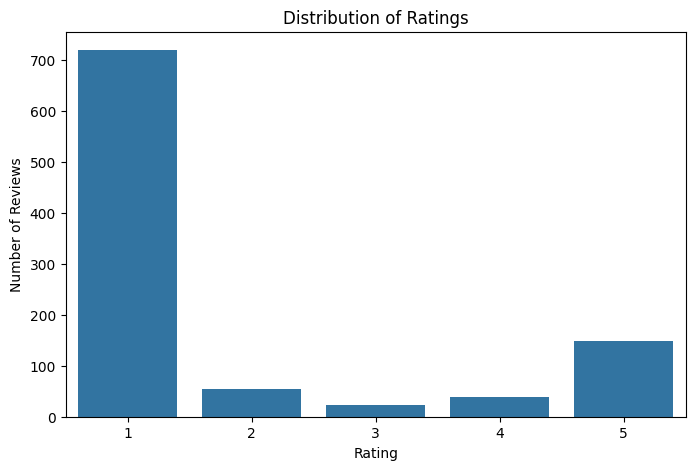

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x="Rating"
)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

**EDA — Step 3: Sentiment Distribution**

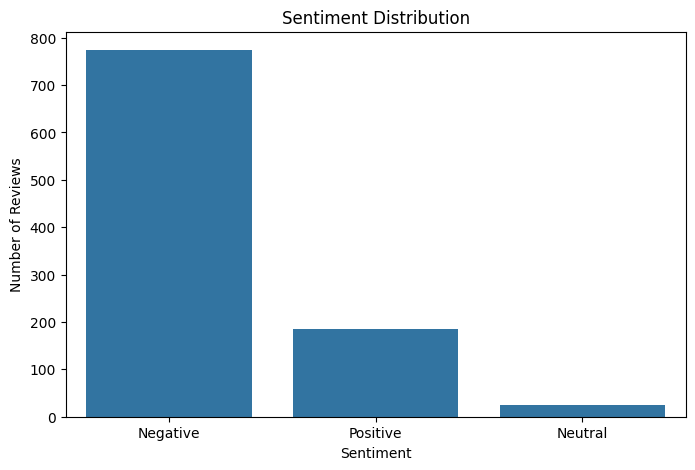

In [127]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x="Sentiment"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

**EDA — Step 4: Reviews by Company**

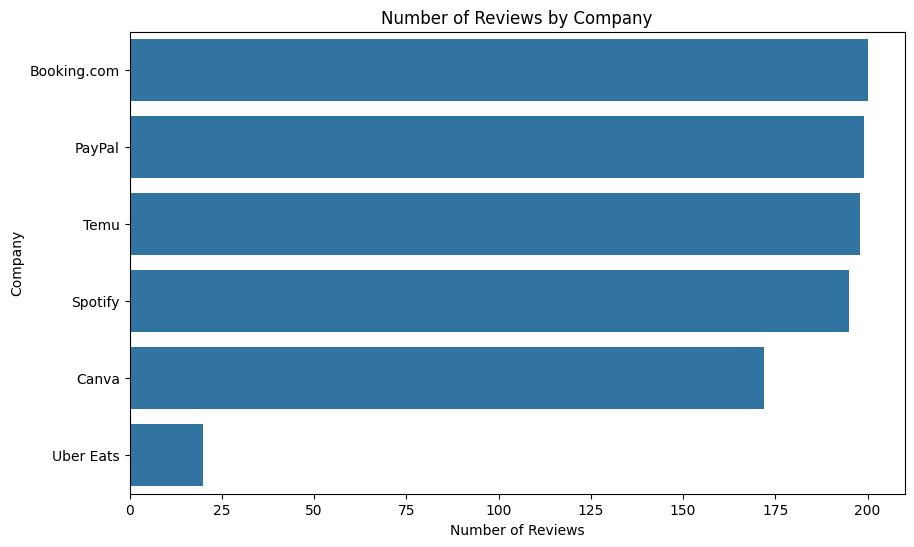

In [128]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=clean_df,
    y="Company",
    order=clean_df["Company"].value_counts().index
)

plt.title("Number of Reviews by Company")
plt.xlabel("Number of Reviews")
plt.ylabel("Company")

plt.show()

**EDA — Step 5: Average Rating by Company ⭐**

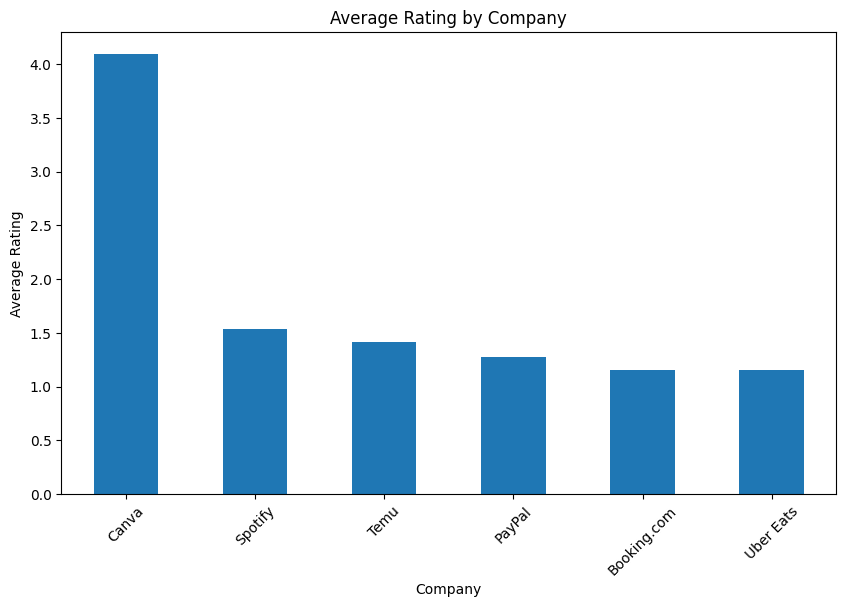

In [129]:
company_rating = (
    clean_df
    .groupby("Company")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

company_rating.plot(
    kind="bar"
)

plt.title("Average Rating by Company")
plt.xlabel("Company")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

In [130]:
print(
    company_rating.round(2)
)

Company
Canva          4.09
Spotify        1.54
Temu           1.41
PayPal         1.28
Booking.com    1.16
Uber Eats      1.15
Name: Rating, dtype: float64


**EDA — Step 6: Sentiment by Company**

In [131]:
sentiment_company = pd.crosstab(
    clean_df["Company"],
    clean_df["Sentiment"]
)

print(sentiment_company)

Sentiment    Negative  Neutral  Positive
Company                                 
Booking.com       192        0         8
Canva              31       10       131
PayPal            186        0        13
Spotify           168        7        20
Temu              178        7        13
Uber Eats          19        0         1


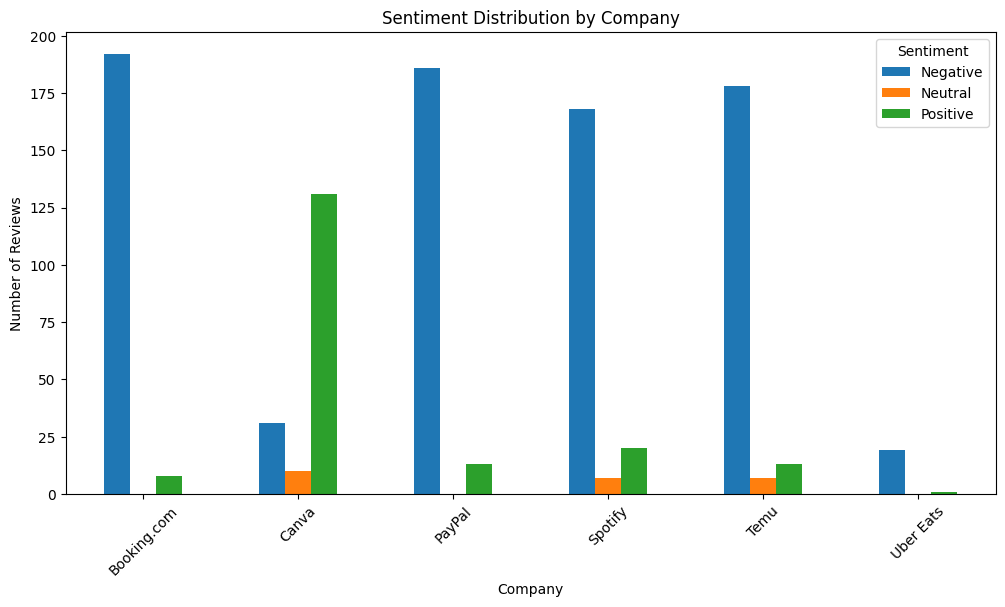

In [132]:
sentiment_company.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Sentiment Distribution by Company")
plt.xlabel("Company")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.legend(
    title="Sentiment"
)

plt.show()

**EDA — Step 7: Sentiment Percentage by Company**

In [133]:
sentiment_percentage = pd.crosstab(
    clean_df["Company"],
    clean_df["Sentiment"],
    normalize="index"
) * 100

print(
    sentiment_percentage.round(2)
)

Sentiment    Negative  Neutral  Positive
Company                                 
Booking.com     96.00     0.00      4.00
Canva           18.02     5.81     76.16
PayPal          93.47     0.00      6.53
Spotify         86.15     3.59     10.26
Temu            89.90     3.54      6.57
Uber Eats       95.00     0.00      5.00


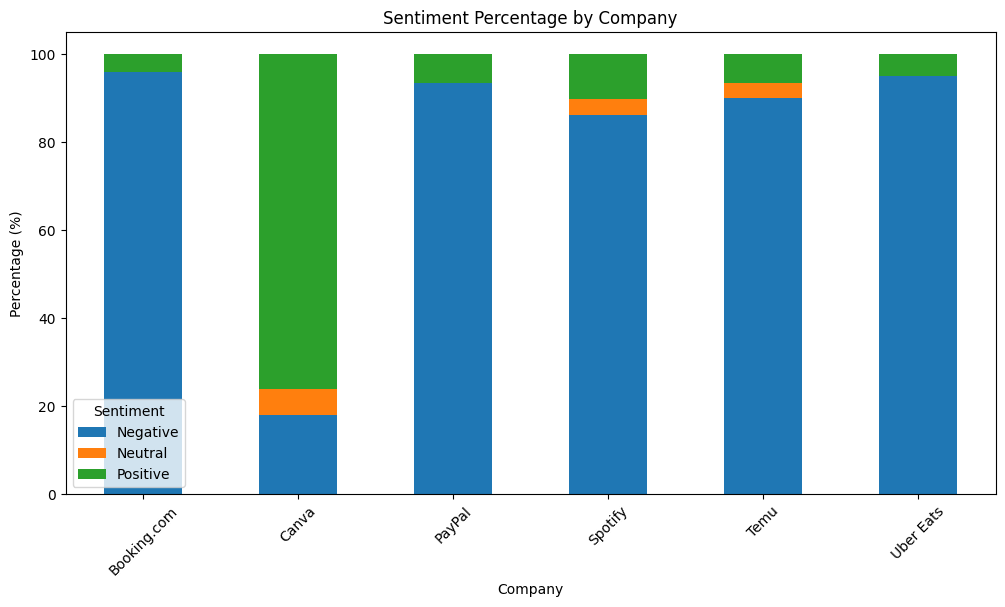

In [134]:
sentiment_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Sentiment Percentage by Company")
plt.xlabel("Company")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=45)

plt.legend(
    title="Sentiment"
)

plt.show()

**EDA — Step 8: Review Length**

In [135]:
clean_df["Review_Length"] = clean_df["Review Text"].str.len()

In [136]:
print(
    clean_df["Review_Length"].describe()
)

count     984.000000
mean      501.858740
std       564.141542
min        11.000000
25%       157.750000
50%       336.500000
75%       618.000000
max      4945.000000
Name: Review_Length, dtype: float64


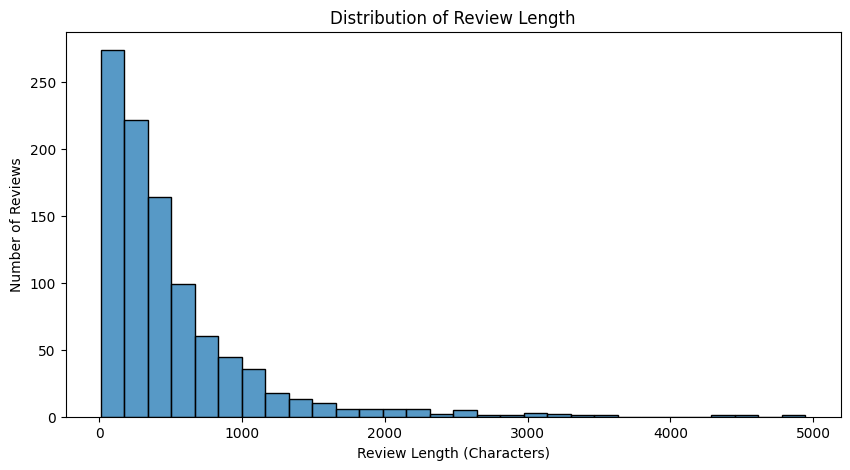

In [137]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=clean_df,
    x="Review_Length",
    bins=30
)

plt.title("Distribution of Review Length")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Number of Reviews")

plt.show()

**EDA — Step 9: Review Length by Sentiment**

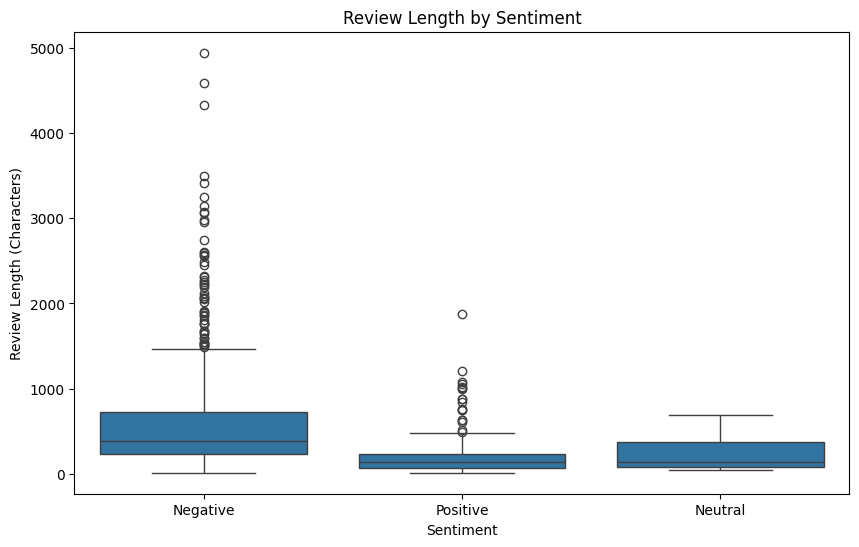

In [138]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=clean_df,
    x="Sentiment",
    y="Review_Length"
)

plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (Characters)")

plt.show()

**Overall sentiment distribution**

Sentiment
Negative    774
Positive    186
Neutral      24
Name: count, dtype: int64


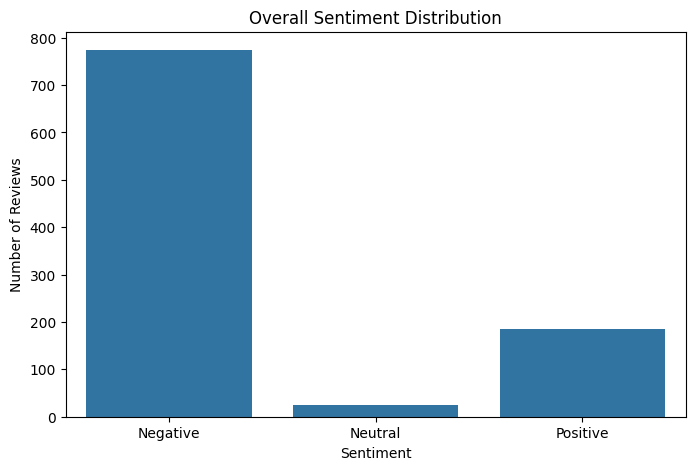

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_counts = clean_df["Sentiment"].value_counts()

print(sentiment_counts)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=clean_df,
    x="Sentiment",
    order=["Negative", "Neutral", "Positive"]
)

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

**2. Sentiment percentage**

In [140]:
sentiment_percent = (
    clean_df["Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_percent)

Sentiment
Negative    78.66
Positive    18.90
Neutral      2.44
Name: proportion, dtype: float64


**3. Sentiment by company**

In [141]:
company_sentiment = pd.crosstab(
    clean_df["Company"],
    clean_df["Sentiment"]
)

print(company_sentiment)

Sentiment    Negative  Neutral  Positive
Company                                 
Booking.com       192        0         8
Canva              31       10       131
PayPal            186        0        13
Spotify           168        7        20
Temu              178        7        13
Uber Eats          19        0         1


In [142]:
company_sentiment = company_sentiment.reindex(
    columns=["Negative", "Neutral", "Positive"],
    fill_value=0
)

print(company_sentiment)

Sentiment    Negative  Neutral  Positive
Company                                 
Booking.com       192        0         8
Canva              31       10       131
PayPal            186        0        13
Spotify           168        7        20
Temu              178        7        13
Uber Eats          19        0         1


**4. Visualize sentiment by company**

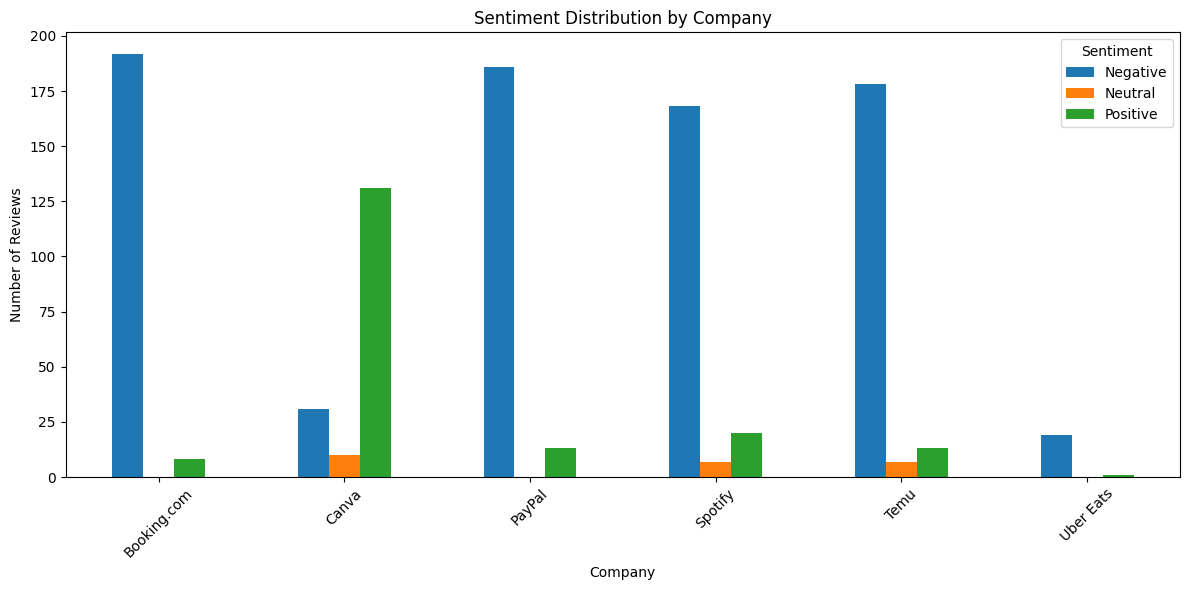

In [143]:
company_sentiment.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Sentiment Distribution by Company")
plt.xlabel("Company")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

**5. Percentage-based company comparison**

In [144]:
company_sentiment_pct = pd.crosstab(
    clean_df["Company"],
    clean_df["Sentiment"],
    normalize="index"
).mul(100).round(2)

company_sentiment_pct = company_sentiment_pct.reindex(
    columns=["Negative", "Neutral", "Positive"],
    fill_value=0
)

print(company_sentiment_pct)

Sentiment    Negative  Neutral  Positive
Company                                 
Booking.com     96.00     0.00      4.00
Canva           18.02     5.81     76.16
PayPal          93.47     0.00      6.53
Spotify         86.15     3.59     10.26
Temu            89.90     3.54      6.57
Uber Eats       95.00     0.00      5.00


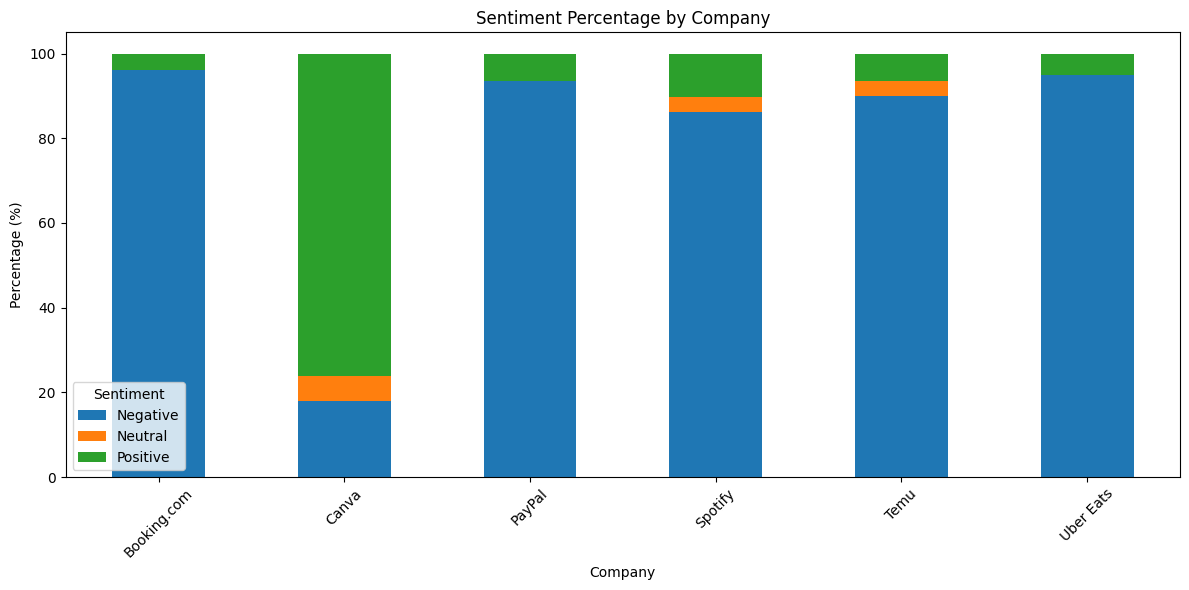

In [145]:
company_sentiment_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Sentiment Percentage by Company")
plt.xlabel("Company")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

**6. Average rating by company**

In [146]:
avg_rating = (
    clean_df
    .groupby("Company")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_rating.round(2))

Company
Canva          4.09
Spotify        1.54
Temu           1.41
PayPal         1.28
Booking.com    1.16
Uber Eats      1.15
Name: Rating, dtype: float64


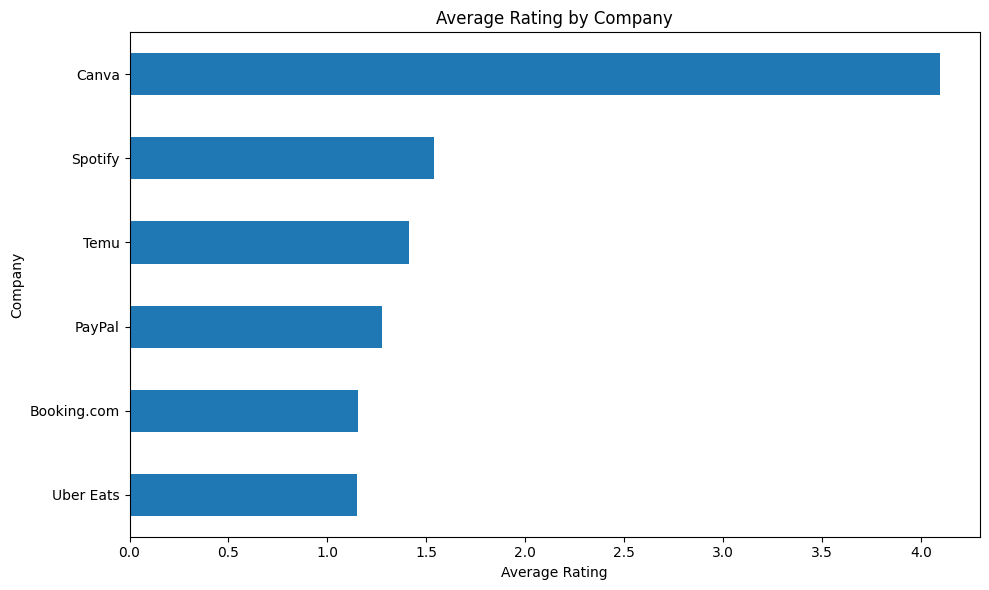

In [147]:
plt.figure(figsize=(10, 6))

avg_rating.sort_values().plot(
    kind="barh"
)

plt.title("Average Rating by Company")
plt.xlabel("Average Rating")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

**7. Create a sentiment score ⭐**

In [148]:
sentiment_score_map = {
    "Negative": -1,
    "Neutral": 0,
    "Positive": 1
}

clean_df["Sentiment_Score"] = (
    clean_df["Sentiment"]
    .map(sentiment_score_map)
)

In [149]:
company_sentiment_score = (
    clean_df
    .groupby("Company")["Sentiment_Score"]
    .mean()
    .sort_values(ascending=False)
)

print(company_sentiment_score.round(3))

Company
Canva          0.581
Spotify       -0.759
Temu          -0.833
PayPal        -0.869
Uber Eats     -0.900
Booking.com   -0.920
Name: Sentiment_Score, dtype: float64


**8. Most negative companies**

In [150]:
print(
    company_sentiment_score
    .sort_values()
    .round(3)
)

Company
Booking.com   -0.920
Uber Eats     -0.900
PayPal        -0.869
Temu          -0.833
Spotify       -0.759
Canva          0.581
Name: Sentiment_Score, dtype: float64


**9. Final sentiment summary table**

In [151]:
sentiment_summary = pd.DataFrame({
    "Reviews": clean_df.groupby("Company").size(),
    "Average Rating": clean_df.groupby("Company")["Rating"].mean(),
    "Sentiment Score": clean_df.groupby("Company")["Sentiment_Score"].mean()
})

sentiment_summary["Negative %"] = (
    clean_df["Sentiment"].eq("Negative")
    .groupby(clean_df["Company"])
    .mean() * 100
)

sentiment_summary["Neutral %"] = (
    clean_df["Sentiment"].eq("Neutral")
    .groupby(clean_df["Company"])
    .mean() * 100
)

sentiment_summary["Positive %"] = (
    clean_df["Sentiment"].eq("Positive")
    .groupby(clean_df["Company"])
    .mean() * 100
)

sentiment_summary = sentiment_summary.round(2)

display(
    sentiment_summary.sort_values(
        "Sentiment Score",
        ascending=False
    )
)

,Reviews,Average Rating,Sentiment Score,Negative %,Neutral %,Positive %
Company,,,,,,
Canva,172,4.09,0.58,18.02,5.81,76.16
Spotify,195,1.54,-0.76,86.15,3.59,10.26
Temu,198,1.41,-0.83,89.90,3.54,6.57
PayPal,199,1.28,-0.87,93.47,0.00,6.53
Uber Eats,20,1.15,-0.90,95.00,0.00,5.00
Booking.com,200,1.16,-0.92,96.00,0.00,4.00


. Overall sentiment

Your 984 reviews contain:

Sentiment	Reviews	%
🔴 Negative	774	78.66%
🟡 Neutral	24	2.44%
🟢 Positive	186	18.90%
Main finding

Nearly 4 out of every 5 reviews are negative.

This means our dataset is highly imbalanced, especially because the Neutral class has only 24 reviews.

2. Company comparison

Your results are:

Company	Reviews	Avg Rating	Negative	Neutral	Positive	Sentiment Score
Canva	172	4.09	18.02%	5.81%	76.16%	+0.581
Spotify	195	1.54	86.15%	3.59%	10.26%	-0.759
Temu	198	1.41	89.90%	3.54%	6.57%	-0.833
PayPal	199	1.28	93.47%	0%	6.53%	-0.869
Uber Eats	20	1.15	95.00%	0%	5.00%	-0.900
Booking.com	200	1.16	96.00%	0%	4.00%	-0.920
3. 🏆 Best company: Canva

Canva is dramatically different from the others:

Positive:  76.16%
Negative:  18.02%
Neutral:    5.81%

Average rating:

4.09 / 5 ⭐

Sentiment score:

+0.581

So based on this collected sample, Canva has the strongest customer sentiment.

4. 🔴 Most negative: Booking.com

Booking.com has:

Negative: 96%
Positive: 4%
Neutral: 0%

Average rating:

1.16 / 5 ⭐

Sentiment score:

-0.920

So Booking.com has the most negative sentiment in this dataset.

However, there's an important research limitation:

These are the reviews our scraper collected, not a random statistical sample of all Trustpilot reviews.

So we should phrase the report as:

"Among the collected Trustpilot reviews, Booking.com showed the most negative sentiment."

rather than saying:

"Booking.com customers are the most dissatisfied."

That's much more scientifically correct.

5. ⚠️ Very important discovery about our dataset

There's something unusual here.

Canva:

4.09 average rating

while Booking.com:

1.16 average rating

That's a huge difference.

And Uber Eats has only:

20 reviews

while Booking.com has:

200 reviews

Therefore, when comparing companies, we should consider sample size.

Especially don't overinterpret Uber Eats's 95% negative rate because it is based on only 20 reviews.

6. Why is the dataset so negative?

This is actually something we should mention in your project.

People who leave reviews on review platforms may be more likely to post after a bad experience than after a normal experience.

So the 78.66% negative rate doesn't necessarily mean:

"78.66% of all customers are unhappy."

It means:

78.66% of the reviews collected in our dataset were classified as negative.

That's an important distinction for your final report.

7. One thing we should NOT do yet

Don't train the ML model yet.

We need to handle the class imbalance first.

Current distribution:

Negative    774  ███████████████████████████████████████
Positive    186  █████████
Neutral      24  █

The Neutral class is especially problematic.

Later we'll use techniques such as:

Stratified train/test split
Class weights
Possibly oversampling
Appropriate metrics: Precision, Recall, F1-score
Confusion Matrix

And importantly, we should not use SMOTE directly on raw text. If we use oversampling, we'll do it appropriately after converting text into numerical features.

🚀 Next step: NLP Text Preprocessing

Now we've completed:

✅ Data Collection
✅ Dataset Combination
✅ Data Inspection
✅ Missing-value inspection
✅ Duplicate inspection
✅ Sentiment labeling
✅ Sentiment Analysis

Next:

Review Text
     ↓
Lowercase
     ↓
Remove HTML / URLs
     ↓
Remove unwanted characters
     ↓
Normalize whitespace
     ↓
Tokenization
     ↓
Stopword handling
     ↓
TF-IDF
     ↓
Machine Learning
One important decision

For sentiment analysis, I recommend we keep negation words such as:

not, no, never, didn't, don't

because:

"good"

and

"not good"

have completely different sentiment.

So we shouldn't blindly remove every stopword.

**NLP Text Preprocessing**

**Step 1 — Install/import NLP tools**

In [152]:
import re
import nltk

from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

# Keep important negation words
negation_words = {
    "no", "not", "never", "neither", "nor",
    "don't", "doesn't", "didn't", "isn't",
    "aren't", "wasn't", "weren't", "won't",
    "wouldn't", "couldn't", "shouldn't", "can't",
    "cannot"
}

stop_words = stop_words - negation_words

print("Stopwords:", len(stop_words))

Stopwords: 184


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Step 2 — Create the cleaning function**

In [153]:
def clean_text(text):

    # Convert to string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", "", text)

    # Keep letters, numbers, apostrophes and spaces
    text = re.sub(r"[^a-z0-9\s']", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords but keep negations
    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

**Step 3 — Apply it**

In [154]:
clean_df["Clean_Text"] = clean_df["Review Text"].apply(
    clean_text
)

**Step 4 — Compare original vs cleaned**

In [155]:
display(
    clean_df[
        ["Review Text", "Clean_Text", "Sentiment"]
    ].head(10)
)

,Review Text,Clean_Text,Sentiment
0,One star is extremely generous for a company t...,one star extremely generous company takes no a...,Negative
1,I WISH YOU COULD LEAVE A NEGATIVE RATING. THIS...,wish could leave negative rating mob unbelieva...,Negative
2,Uber Eats is an absolute rip off. The menu pri...,uber eats absolute rip menu prices higher stor...,Negative
3,I had some negative experiences in the past wi...,negative experiences past ubereats friend real...,Negative
4,This got to be the worst company that you can ...,got worst company use delivery food placed siz...,Negative
5,"The delivery guy did not deliver my food , he ...",delivery guy not deliver food went back home e...,Negative
6,Still battling an non order of main food( no d...,still battling non order main food no delivery...,Negative
7,Costumer service is very bad. I was promised i...,costumer service bad promised chat month messa...,Negative
8,I've spent a lot of time being annoyed at Uber...,spent lot time annoyed uber eats long delivery...,Positive
9,"Uber kept pushing the delivery time later, the...",uber kept pushing delivery time later refused ...,Negative


**Step 5 — Check empty reviews**

In [156]:
empty_reviews = clean_df[
    clean_df["Clean_Text"].str.strip() == ""
]

print("Empty cleaned reviews:", len(empty_reviews))

Empty cleaned reviews: 1


**Step 6 — Calculate text statistics**

In [157]:
clean_df["Word_Count"] = (
    clean_df["Clean_Text"]
    .str.split()
    .str.len()
)

clean_df["Character_Count"] = (
    clean_df["Clean_Text"]
    .str.len()
)

print(clean_df[
    ["Word_Count", "Character_Count"]
].describe())

       Word_Count  Character_Count
count  984.000000       984.000000
mean    47.695122       329.680894
std     52.475897       382.213319
min      0.000000         0.000000
25%     16.000000       103.750000
50%     32.000000       215.000000
75%     59.000000       395.000000
max    451.000000      3536.000000


**Step 7 — Check before/after cleaning**

In [158]:
print("Original example:")
print(clean_df["Review Text"].iloc[0])

print("\nCleaned example:")
print(clean_df["Clean_Text"].iloc[0])

Original example:
One star is extremely generous for a company that takes no accountability for their delivery contractors. No customer support, and an app that progresses as if everything went good even when it doesn’t. I feel bad for the restaurants that take time to prepare food that gets ruined by the delivery process. Just go pick up your order if you don’t want it ruined by this so called service.

Cleaned example:
one star extremely generous company takes no accountability delivery contractors no customer support app progresses everything went good even feel bad restaurants take time prepare food gets ruined delivery process go pick order want ruined called service


In [159]:
empty_reviews = clean_df[
    clean_df["Clean_Text"].str.strip() == ""
]

display(
    empty_reviews[
        ["Company", "Review Title", "Review Text", "Rating", "Sentiment"]
    ]
)

,Company,Review Title,Review Text,Rating,Sentiment
239,Spotify,THE DO😍THE DO😍THE DO😍THE DO😍THE DO😍THE…,THE DO😍THE DO😍THE DO😍THE DO😍THE DO😍THE DO😍THE ...,1,Negative


In [160]:
clean_df = clean_df[
    clean_df["Clean_Text"].str.strip() != ""
].copy()

print("New dataset shape:", clean_df.shape)

New dataset shape: (983, 14)


**Next: remove the one empty review**

In [161]:
empty_reviews = clean_df[
    clean_df["Clean_Text"].str.strip() == ""
]

display(
    empty_reviews[
        ["Company", "Review Title", "Review Text", "Rating", "Sentiment"]
    ]
)

,Company,Review Title,Review Text,Rating,Sentiment


**TF-IDF**

**1. Check the final sentiment distribution**

In [162]:
print(clean_df["Sentiment"].value_counts())

Sentiment
Negative    773
Positive    186
Neutral      24
Name: count, dtype: int64


In [163]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X = tfidf.fit_transform(clean_df["Clean_Text"])

y = clean_df["Sentiment"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))

X shape: (983, 5000)
y shape: (983,)
Vocabulary size: 5000


**2. Inspect the TF-IDF features**

In [164]:
feature_names = tfidf.get_feature_names_out()

print("First 50 features:")
print(feature_names[:50])

First 50 features:
['00' '00 refund' '000' '01' '037' '05' '06' '07' '08' '10' '10 days'
 '10 item' '10 items' '10 minutes' '10 years' '100' '1000' '11' '12'
 '12 99' '120' '120 days' '125' '128' '13' '130' '135' '14' '14 days'
 '1400' '144' '15' '15 20' '15 days' '15 hours' '15 minutes' '150' '15th'
 '16' '17' '18' '19' '1st' '20' '20 mins' '20 years' '200' '2025' '2026'
 '21']


In [165]:
print("Total features:", len(feature_names))

Total features: 5000


**Step 1 — Proper Train/Test Split**

In [166]:
from sklearn.model_selection import train_test_split

X_text = clean_df["Clean_Text"]
y = clean_df["Sentiment"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training samples: 786
Testing samples: 197

Training distribution:
Sentiment
Negative    618
Positive    149
Neutral      19
Name: count, dtype: int64

Testing distribution:
Sentiment
Negative    155
Positive     37
Neutral       5
Name: count, dtype: int64


**Step 2 — Fit TF-IDF ONLY on training data**

In [167]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train = tfidf.fit_transform(X_train_text)

X_test = tfidf.transform(X_test_text)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))

X_train shape: (786, 5000)
X_test shape: (197, 5000)
Vocabulary size: 5000


**Step 3 — Check class distribution**

In [168]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
Sentiment
Negative    618
Positive    149
Neutral      19
Name: count, dtype: int64

Testing class distribution:
Sentiment
Negative    155
Positive     37
Neutral       5
Name: count, dtype: int64


**Step 4 — Check TF-IDF features**

In [169]:
feature_names = tfidf.get_feature_names_out()

print("Total features:", len(feature_names))
print("\nFirst 50 features:")
print(feature_names[:50])

Total features: 5000

First 50 features:
['00' '037' '05' '06' '07' '10' '10 days' '10 item' '10 minutes'
 '10 years' '100' '1000' '1000 streams' '11' '11th' '12' '12 99' '120'
 '128' '13' '130' '14' '1400' '15' '15 hours' '150' '16' '17' '18' '19'
 '20' '20 mins' '20 years' '200' '2025' '2026' '21' '21 days' '24'
 '24 hours' '25' '2500' '26' '27th' '29' '2nd' '2nd time' '30' '300'
 '31st']


**Model 1 — Logistic Regression**

In [170]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:")
print(round(accuracy_score(y_test, y_pred_lr), 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.9036

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.99      0.95       155
     Neutral       0.00      0.00      0.00         5
    Positive       0.89      0.68      0.77        37

    accuracy                           0.90       197
   macro avg       0.60      0.55      0.57       197
weighted avg       0.89      0.90      0.89       197


Confusion Matrix:
[[153   0   2]
 [  4   0   1]
 [ 10   2  25]]


**Also generate the confusion matrix visually**

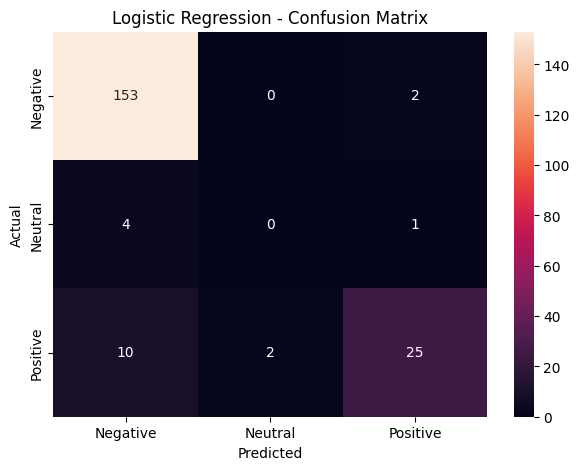

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=["Negative", "Neutral", "Positive"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Save the model results**

In [172]:
from sklearn.metrics import precision_score, recall_score, f1_score

lr_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(
        y_test, y_pred_lr,
        average="macro",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test, y_pred_lr,
        average="macro",
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test, y_pred_lr,
        average="macro",
        zero_division=0
    )
}

print(lr_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.9035532994923858, 'Precision': 0.6030082691759339, 'Recall': 0.5542574832897413, 'F1 Score': 0.5731804427456602}


**Model 2 — Multinomial Naive Bayes**

In [174]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:")
print(round(accuracy_score(y_test, y_pred_nb), 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_nb,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_nb,
    labels=["Negative", "Neutral", "Positive"]
))

Naive Bayes Accuracy:
0.8223

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      1.00      0.90       155
     Neutral       0.00      0.00      0.00         5
    Positive       1.00      0.19      0.32        37

    accuracy                           0.82       197
   macro avg       0.61      0.40      0.41       197
weighted avg       0.83      0.82      0.77       197


Confusion Matrix:
[[155   0   0]
 [  5   0   0]
 [ 30   0   7]]


In [175]:
nb_results = {
    "Model": "Multinomial Naive Bayes",
    "Accuracy": accuracy_score(y_test, y_pred_nb),
    "Precision": precision_score(
        y_test,
        y_pred_nb,
        average="macro",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_nb,
        average="macro",
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        y_pred_nb,
        average="macro",
        zero_division=0
    )
}

print(nb_results)

{'Model': 'Multinomial Naive Bayes', 'Accuracy': 0.8223350253807107, 'Precision': 0.6052631578947368, 'Recall': 0.3963963963963964, 'F1 Score': 0.4055775142731664}


**Model 3 — Linear SVM**

In [176]:
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("Linear SVM Accuracy:")
print(round(accuracy_score(y_test, y_pred_svm), 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_svm,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_svm,
    labels=["Negative", "Neutral", "Positive"]
))

Linear SVM Accuracy:
0.8934

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.99      0.94       155
     Neutral       0.00      0.00      0.00         5
    Positive       0.92      0.59      0.72        37

    accuracy                           0.89       197
   macro avg       0.60      0.53      0.55       197
weighted avg       0.87      0.89      0.87       197


Confusion Matrix:
[[154   0   1]
 [  4   0   1]
 [ 15   0  22]]


In [177]:
svm_results = {
    "Model": "Linear SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(
        y_test,
        y_pred_svm,
        average="macro",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_svm,
        average="macro",
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        y_pred_svm,
        average="macro",
        zero_division=0
    )
}

print(svm_results)

{'Model': 'Linear SVM', 'Accuracy': 0.8934010152284264, 'Precision': 0.6022800256904303, 'Recall': 0.5293809938971229, 'F1 Score': 0.5534452885512461}


**Model 4 — Random Forest**

In [178]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:")
print(round(accuracy_score(y_test, y_pred_rf), 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["Negative", "Neutral", "Positive"]
))

Random Forest Accuracy:
0.8934

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      1.00      0.94       155
     Neutral       0.00      0.00      0.00         5
    Positive       1.00      0.57      0.72        37

    accuracy                           0.89       197
   macro avg       0.63      0.52      0.55       197
weighted avg       0.88      0.89      0.87       197


Confusion Matrix:
[[155   0   0]
 [  5   0   0]
 [ 16   0  21]]


In [179]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(
        y_test,
        y_pred_rf,
        average="macro",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_rf,
        average="macro",
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        y_pred_rf,
        average="macro",
        zero_division=0
    )
}

print(rf_results)

{'Model': 'Random Forest', 'Accuracy': 0.8934010152284264, 'Precision': 0.6268939393939394, 'Recall': 0.5225225225225225, 'F1 Score': 0.5535646074243844}


All 4 models are now trained and evaluated. ✅

🏆 Final Model Comparison
Model	Accuracy	Macro Precision	Macro Recall	Macro F1
🥇 Logistic Regression	90.36%	60.30%	55.43%	57.32%
Random Forest	89.34%	62.69%	52.25%	55.36%
Linear SVM	89.34%	60.23%	52.94%	55.34%
Naive Bayes	82.23%	60.53%	39.64%	40.56%
🥇 Best model: Logistic Regression

Your best model is:

Logistic Regression — Accuracy: 90.36%, Macro F1: 57.32%

However, there's an important observation:

⚠️ Neutral class problem

All four models produced:

Neutral Recall = 0%
Neutral F1     = 0%

That's because we only have:

Total Neutral reviews = 24
Training Neutral      = 19
Testing Neutral       = 5

So the dataset is heavily imbalanced:

Negative = 773 → 78.64%
Positive = 186 → 18.92%
Neutral  = 24  → 2.44%

**Now let's create the model comparison visualization**

In [180]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame([
    lr_results,
    nb_results,
    svm_results,
    rf_results
])

print(results)

                     Model  Accuracy  Precision    Recall  F1 Score
0      Logistic Regression  0.903553   0.603008  0.554257  0.573180
1  Multinomial Naive Bayes  0.822335   0.605263  0.396396  0.405578
2               Linear SVM  0.893401   0.602280  0.529381  0.553445
3            Random Forest  0.893401   0.626894  0.522523  0.553565


**1. Accuracy comparison**

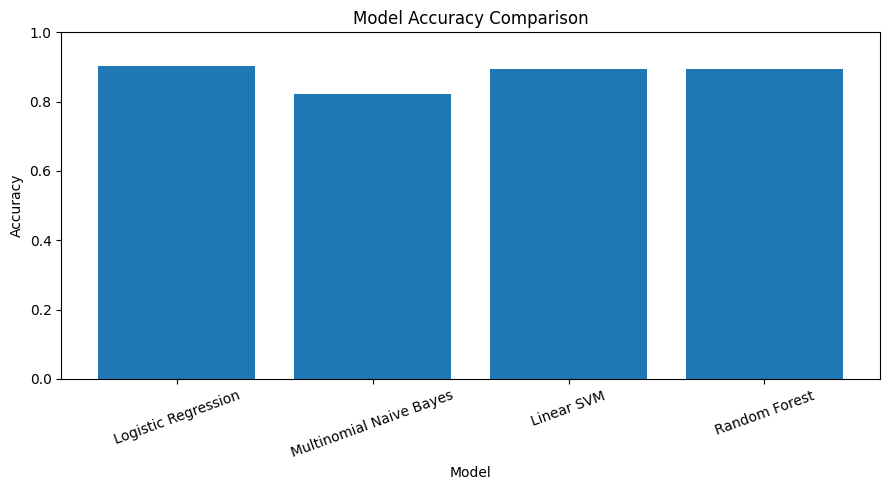

In [181]:
plt.figure(figsize=(9, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**2. Macro F1 comparison**

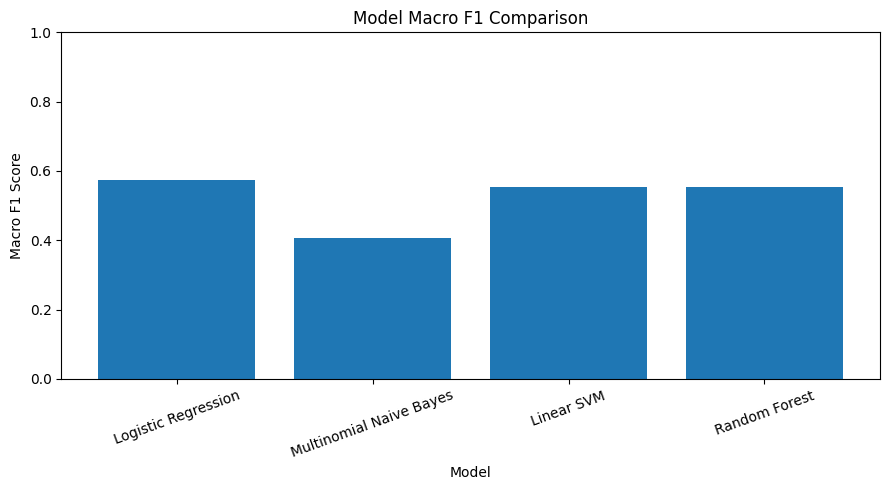

In [182]:
plt.figure(figsize=(9, 5))

plt.bar(
    results["Model"],
    results["F1 Score"]
)

plt.title("Model Macro F1 Comparison")
plt.xlabel("Model")
plt.ylabel("Macro F1 Score")

plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**3. All metrics comparison**

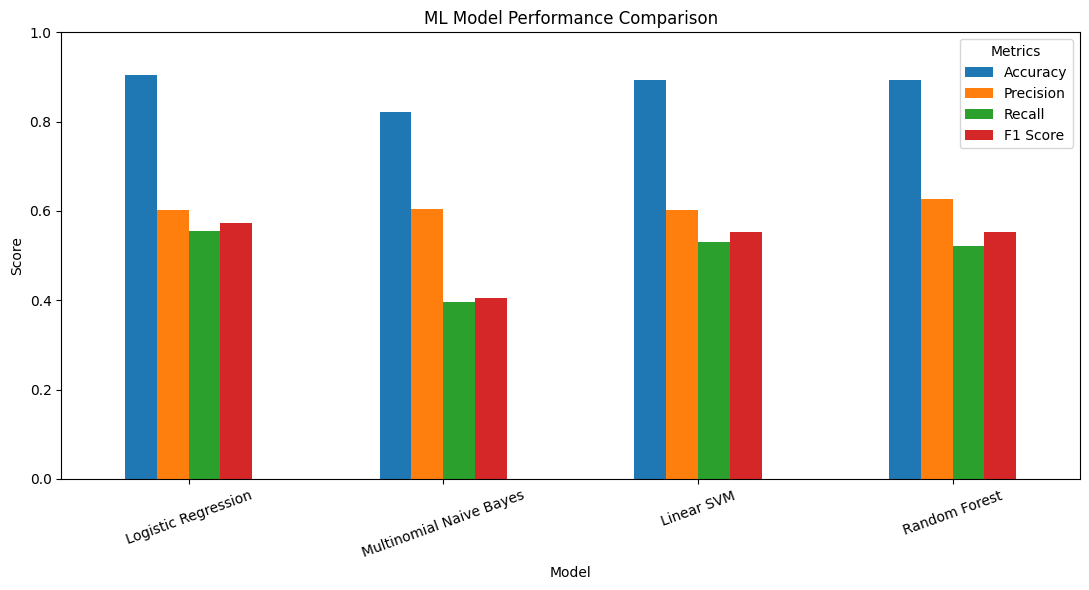

In [183]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

results_plot = results.set_index("Model")[metrics]

results_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("ML Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.legend(title="Metrics")

plt.tight_layout()
plt.show()

fix the class imbalance properly

Step 1 — Check current training distribution

In [184]:
print("Before balancing:")
print(y_train.value_counts())

Before balancing:
Sentiment
Negative    618
Positive    149
Neutral      19
Name: count, dtype: int64


**Step 2 — Apply Random Oversampling**

In [185]:
!pip install -q imbalanced-learn

In [186]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
    random_state=42
)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train,
    y_train
)

print("After balancing:")
print(y_train_balanced.value_counts())

print("\nOriginal training shape:", X_train.shape)
print("Balanced training shape:", X_train_balanced.shape)

After balancing:
Sentiment
Negative    618
Positive    618
Neutral     618
Name: count, dtype: int64

Original training shape: (786, 5000)
Balanced training shape: (1854, 5000)


**Step 3 — Train Logistic Regression again**

In [187]:
lr_balanced = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr_balanced.fit(
    X_train_balanced,
    y_train_balanced
)

y_pred_lr_balanced = lr_balanced.predict(X_test)

**Step 4 — Evaluate**

In [188]:
print("Balanced Logistic Regression Accuracy:")
print(round(
    accuracy_score(y_test, y_pred_lr_balanced),
    4
))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_lr_balanced,
        zero_division=0
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred_lr_balanced,
        labels=["Negative", "Neutral", "Positive"]
    )
)

Balanced Logistic Regression Accuracy:
0.9036

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.99      0.95       155
     Neutral       0.00      0.00      0.00         5
    Positive       0.92      0.65      0.76        37

    accuracy                           0.90       197
   macro avg       0.61      0.55      0.57       197
weighted avg       0.89      0.90      0.89       197


Confusion Matrix:
[[154   0   1]
 [  4   0   1]
 [ 12   1  24]]


**Step 5 — Calculate Macro F1**

In [189]:
balanced_lr_results = {
    "Model": "Logistic Regression + Oversampling",
    "Accuracy": accuracy_score(
        y_test,
        y_pred_lr_balanced
    ),
    "Precision": precision_score(
        y_test,
        y_pred_lr_balanced,
        average="macro",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_lr_balanced,
        average="macro",
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        y_pred_lr_balanced,
        average="macro",
        zero_division=0
    )
}

print(balanced_lr_results)

{'Model': 'Logistic Regression + Oversampling', 'Accuracy': 0.9035532994923858, 'Precision': 0.6096530920060332, 'Recall': 0.547399011915141, 'F1 Score': 0.5698656898656899}


**Step 6 — Compare with the original model**

In [190]:
comparison = pd.DataFrame([
    lr_results,
    balanced_lr_results
])

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.903553,0.603008,0.554257,0.573180
1,Logistic Regression + Oversampling,0.903553,0.609653,0.547399,0.569866


**Next: Tune Logistic Regression**

C controls regularization:

Smaller C → stronger regularization → simpler model
Larger C → weaker regularization → more complex model

In [191]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

C_values = [0.01, 0.1, 0.5, 1, 2, 5, 10]

tuning_results = []

for c in C_values:

    model = LogisticRegression(
        C=c,
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    tuning_results.append({
        "C": c,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro_F1": f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        )
    })

tuning_df = pd.DataFrame(tuning_results)

print(tuning_df)

       C  Accuracy  Macro_F1
0   0.01  0.873096  0.548522
1   0.10  0.893401  0.560587
2   0.50  0.903553  0.572561
3   1.00  0.903553  0.573180
4   2.00  0.913706  0.584520
5   5.00  0.908629  0.577289
6  10.00  0.908629  0.577289


In [192]:
best_result = tuning_df.loc[
    tuning_df["Macro_F1"].idxmax()
]

print("\nBest Parameters:")
print(best_result)


Best Parameters:
C           2.000000
Accuracy    0.913706
Macro_F1    0.584520
Name: 4, dtype: float64


Now create the final tuned model

Don't use the old lr_model. Train the final model with C=2: **bold text**

In [193]:
final_model = LogisticRegression(
    C=2,
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)

In [194]:
print("FINAL MODEL — Logistic Regression (C=2)")

print("\nAccuracy:")
print(round(accuracy_score(y_test, y_pred_final), 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_final,
        labels=["Negative", "Neutral", "Positive"]
    )
)

FINAL MODEL — Logistic Regression (C=2)

Accuracy:
0.9137

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.99      0.95       155
     Neutral       0.00      0.00      0.00         5
    Positive       0.93      0.70      0.80        37

    accuracy                           0.91       197
   macro avg       0.62      0.57      0.58       197
weighted avg       0.90      0.91      0.90       197


Confusion Matrix:
[[154   0   1]
 [  4   0   1]
 [ 10   1  26]]


In [195]:
final_results = {
    "Model": "Logistic Regression (C=2)",
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(
        y_test,
        y_pred_final,
        average="macro",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_final,
        average="macro",
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        y_pred_final,
        average="macro",
        zero_division=0
    )
}

print(final_results)

{'Model': 'Logistic Regression (C=2)', 'Accuracy': 0.9137055837563451, 'Precision': 0.6150793650793651, 'Recall': 0.565417029933159, 'F1 Score': 0.5845201238390093}


**Next step: Feature/Word Importance**

In [197]:
# Check which variables containing "vector" exist
[name for name in globals() if "vector" in name.lower()]

['TfidfVectorizer']

In [201]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_objects = []

for name in list(globals().keys()):
    obj = globals()[name]

    try:
        if isinstance(obj, TfidfVectorizer):
            tfidf_objects.append((name, obj))
    except:
        pass

print("TF-IDF objects found:")

for name, obj in tfidf_objects:
    print(
        f"{name} -> {len(obj.get_feature_names_out())} features"
    )

TF-IDF objects found:
tfidf -> 5000 features


In [202]:
feature_names = tfidf.get_feature_names_out()

coefficients = final_model.coef_
classes = final_model.classes_

print("Classes:", classes)
print("Number of features:", len(feature_names))

Classes: ['Negative' 'Neutral' 'Positive']
Number of features: 5000


In [203]:
import numpy as np
import pandas as pd

feature_names = tfidf.get_feature_names_out()
coefficients = final_model.coef_
classes = final_model.classes_

top_words = {}

for i, class_name in enumerate(classes):

    # Get indices of largest coefficients
    top_indices = np.argsort(coefficients[i])[-20:][::-1]

    top_words[class_name] = pd.DataFrame({
        "Word": feature_names[top_indices],
        "Coefficient": coefficients[i][top_indices]
    })

    print(f"\n{'=' * 50}")
    print(f"TOP 20 WORDS — {class_name}")
    print("=" * 50)

    print(top_words[class_name].to_string(index=False))


TOP 20 WORDS — Negative
       Word  Coefficient
         no     1.813760
        not     1.475190
      money     1.400457
    booking     1.174516
    service     1.114500
   customer     1.090487
     paypal     1.029237
booking com     1.020469
    company     0.994677
        com     0.993718
    account     0.969286
      worst     0.947032
      never     0.916269
   terrible     0.860043
     refund     0.843624
       even     0.828774
      songs     0.806336
       back     0.729392
    payment     0.719440
   horrible     0.702570

TOP 20 WORDS — Neutral
       Word  Coefficient
      music     2.250976
  advertise     2.023801
      shirt     1.843876
       fits     1.810629
   everyone     1.754310
     better     1.682151
       fast     1.660146
       free     1.573568
       good     1.532006
   bit high     1.455355
  atrocious     1.450634
 canva free     1.450074
meaningless     1.429136
      hello     1.418904
  selection     1.404696
   able use     1.333892
 

**Chart 1 — Overall Sentiment Distribution**

In [205]:
# Find all DataFrames containing the Sentiment column

import pandas as pd

sentiment_dfs = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        if "Sentiment" in obj.columns:
            sentiment_dfs.append((name, obj))

print("DataFrames containing 'Sentiment':")

for name, data in sentiment_dfs:
    print(f"{name}: {data.shape}")

DataFrames containing 'Sentiment':
clean_df: (983, 14)
duplicates: (2, 9)
empty_reviews: (0, 14)


**Also show percentages**

Sentiment Counts:
Sentiment
Negative    773
Positive    186
Neutral      24
Name: count, dtype: int64

Sentiment Percentages:
Sentiment
Negative    78.64
Positive    18.92
Neutral      2.44
Name: proportion, dtype: float64


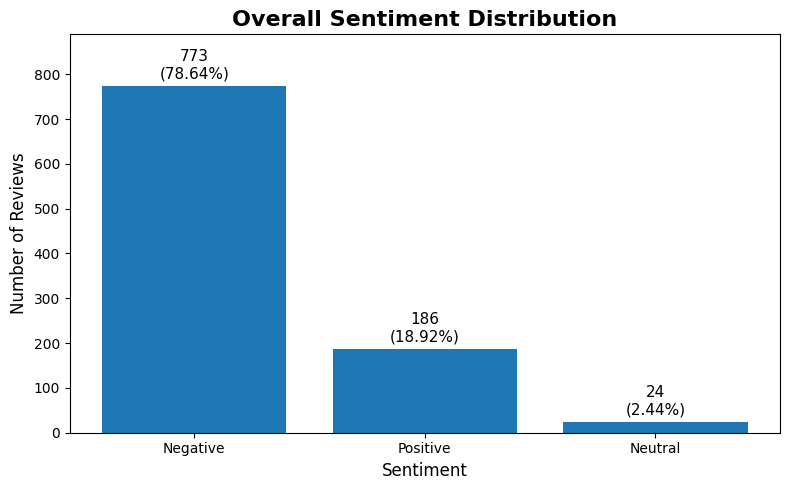

In [207]:
import matplotlib.pyplot as plt

# ============================================
# CHART 1 — OVERALL SENTIMENT DISTRIBUTION
# ============================================

# Use the correct DataFrame
sentiment_counts = clean_df["Sentiment"].value_counts()

print("Sentiment Counts:")
print(sentiment_counts)

# Calculate percentages
sentiment_percentage = (
    clean_df["Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nSentiment Percentages:")
print(sentiment_percentage)

# Create bar chart
plt.figure(figsize=(8, 5))

bars = plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

# Add count + percentage above each bar
for bar, count, percentage in zip(
    bars,
    sentiment_counts.values,
    sentiment_percentage[sentiment_counts.index].values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{count}\n({percentage}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title(
    "Overall Sentiment Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)

plt.ylim(0, max(sentiment_counts.values) * 1.15)

plt.tight_layout()
plt.show()

**Chart 2 — Sentiment Distribution by Company**

Sentiment Distribution by Company:
Sentiment    Negative  Neutral  Positive
Company                                 
Booking.com       192        0         8
Canva              31       10       131
PayPal            186        0        13
Spotify           167        7        20
Temu              178        7        13
Uber Eats          19        0         1


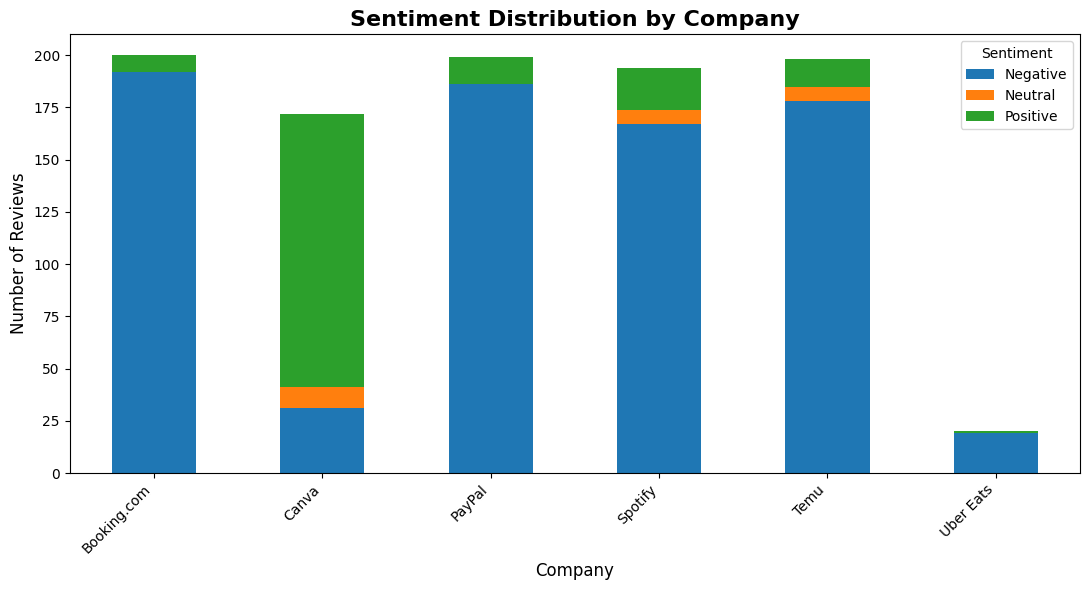

In [208]:
import matplotlib.pyplot as plt

# ============================================
# CHART 2 — SENTIMENT DISTRIBUTION BY COMPANY
# ============================================

company_sentiment = pd.crosstab(
    clean_df["Company"],
    clean_df["Sentiment"]
)

# Make sure all sentiment columns exist
for sentiment in ["Negative", "Neutral", "Positive"]:
    if sentiment not in company_sentiment.columns:
        company_sentiment[sentiment] = 0

# Keep consistent order
company_sentiment = company_sentiment[
    ["Negative", "Neutral", "Positive"]
]

print("Sentiment Distribution by Company:")
print(company_sentiment)

# Create stacked bar chart
ax = company_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title(
    "Sentiment Distribution by Company",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Company", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Sentiment"
)

plt.tight_layout()
plt.show()

In [209]:
# ============================================
# SENTIMENT PERCENTAGE BY COMPANY
# ============================================

company_sentiment_pct = (
    pd.crosstab(
        clean_df["Company"],
        clean_df["Sentiment"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

for sentiment in ["Negative", "Neutral", "Positive"]:
    if sentiment not in company_sentiment_pct.columns:
        company_sentiment_pct[sentiment] = 0

company_sentiment_pct = company_sentiment_pct[
    ["Negative", "Neutral", "Positive"]
]

print("Sentiment Percentage by Company:")
print(company_sentiment_pct)

Sentiment Percentage by Company:
Sentiment    Negative  Neutral  Positive
Company                                 
Booking.com     96.00     0.00      4.00
Canva           18.02     5.81     76.16
PayPal          93.47     0.00      6.53
Spotify         86.08     3.61     10.31
Temu            89.90     3.54      6.57
Uber Eats       95.00     0.00      5.00


**Chart 3 — Average Rating by Company**

Average Rating by Company:
Company
Uber Eats      1.15
Booking.com    1.16
PayPal         1.28
Temu           1.41
Spotify        1.54
Canva          4.09
Name: Rating, dtype: float64


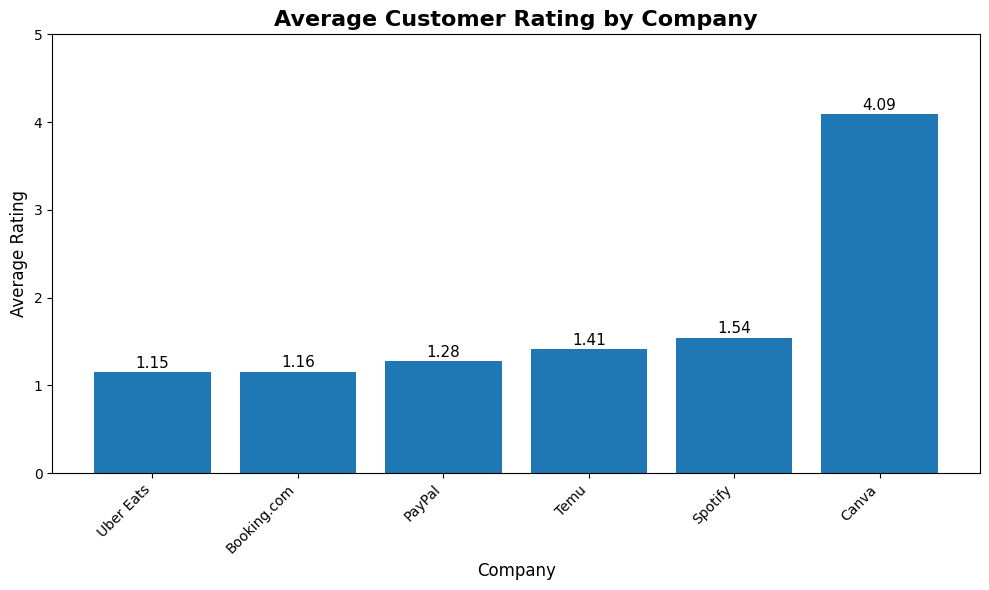

In [210]:
import matplotlib.pyplot as plt

# ============================================
# CHART 3 — AVERAGE RATING BY COMPANY
# ============================================

avg_rating = (
    clean_df
    .groupby("Company")["Rating"]
    .mean()
    .sort_values(ascending=True)
)

print("Average Rating by Company:")
print(avg_rating.round(2))

plt.figure(figsize=(10, 6))

bars = plt.bar(
    avg_rating.index,
    avg_rating.values
)

# Add rating values
for bar, value in zip(bars, avg_rating.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.05,
        f"{value:.2f}",
        ha="center",
        fontsize=11
    )

plt.title(
    "Average Customer Rating by Company",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Company", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)

plt.xticks(rotation=45, ha="right")

plt.ylim(0, 5)

plt.tight_layout()
plt.show()

**Chart 4 — Sentiment Score vs Average Rating**

             Average_Rating  Sentiment_Score  Reviews
Company                                              
Uber Eats             1.150           -0.900       20
Booking.com           1.155           -0.920      200
PayPal                1.276           -0.869      199
Temu                  1.414           -0.833      198
Spotify               1.541           -0.758      194
Canva                 4.093            0.581      172


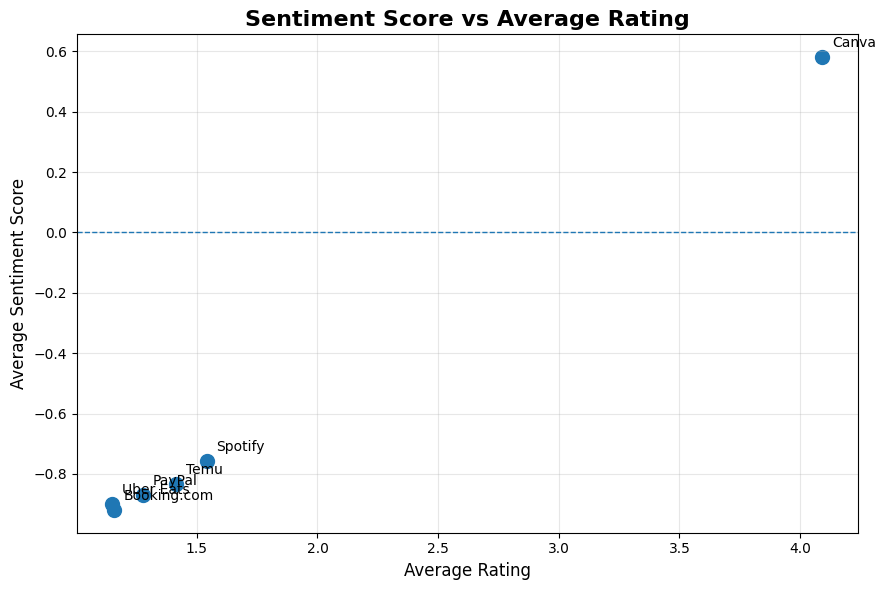

In [211]:
import matplotlib.pyplot as plt

# ============================================
# CHART 4 — SENTIMENT SCORE VS AVERAGE RATING
# ============================================

company_analysis = (
    clean_df
    .groupby("Company")
    .agg(
        Average_Rating=("Rating", "mean"),
        Sentiment_Score=("Sentiment_Score", "mean"),
        Reviews=("Sentiment", "count")
    )
    .sort_values("Average_Rating")
)

print(company_analysis.round(3))

plt.figure(figsize=(9, 6))

plt.scatter(
    company_analysis["Average_Rating"],
    company_analysis["Sentiment_Score"],
    s=100
)

# Label each company
for company, row in company_analysis.iterrows():
    plt.annotate(
        company,
        (
            row["Average_Rating"],
            row["Sentiment_Score"]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=10
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title(
    "Sentiment Score vs Average Rating",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Rating", fontsize=12)
plt.ylabel("Average Sentiment Score", fontsize=12)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

| Company     | Reviews | Avg Rating | Sentiment Score |
| ----------- | ------: | ---------: | --------------: |
| Canva       |     172 |  **4.093** |       **0.581** |
| Spotify     |     194 |      1.541 |          -0.758 |
| Temu        |     198 |      1.414 |          -0.833 |
| PayPal      |     199 |      1.276 |          -0.869 |
| Booking.com |     200 |      1.155 |          -0.920 |
| Uber Eats   |      20 |      1.150 |          -0.900 |


**Chart 5 — Rating Distribution**

Dataset shape: (983, 14)
Columns: ['Company', 'Industry', 'Review Title', 'Review Text', 'Rating', 'Date', 'Review_ID', 'Reviewer', 'Sentiment', 'Review_Length', 'Sentiment_Score', 'Clean_Text', 'Word_Count', 'Character_Count']

Rating Distribution:
Rating
1    719
2     54
3     24
4     38
5    148
Name: count, dtype: int64


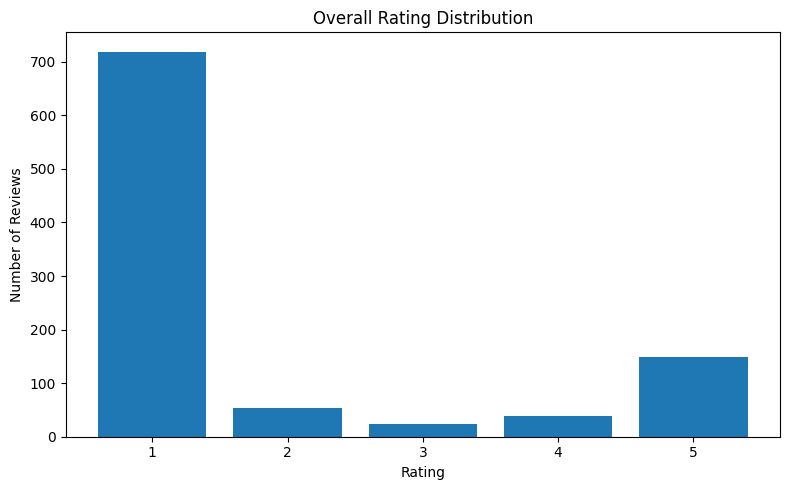

In [212]:
# ------------------------------------------------------------
# Make sure clean_df is available
# ------------------------------------------------------------
print("Dataset shape:", clean_df.shape)
print("Columns:", clean_df.columns.tolist())


# ============================================================
# CHART 5 — OVERALL RATING DISTRIBUTION
# ============================================================

rating_counts = clean_df["Rating"].value_counts().sort_index()

print("\nRating Distribution:")
print(rating_counts)

plt.figure(figsize=(8, 5))

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

plt.title("Overall Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()



**6 → Rating by Company**


Rating Distribution by Company:
Rating         1   2   3   4    5
Company                          
Booking.com  190   2   0   3    5
Canva         26   5  10  17  114
PayPal       181   5   0   2   11
Spotify      146  21   7  10   10
Temu         157  21   7   5    8
Uber Eats     19   0   0   1    0


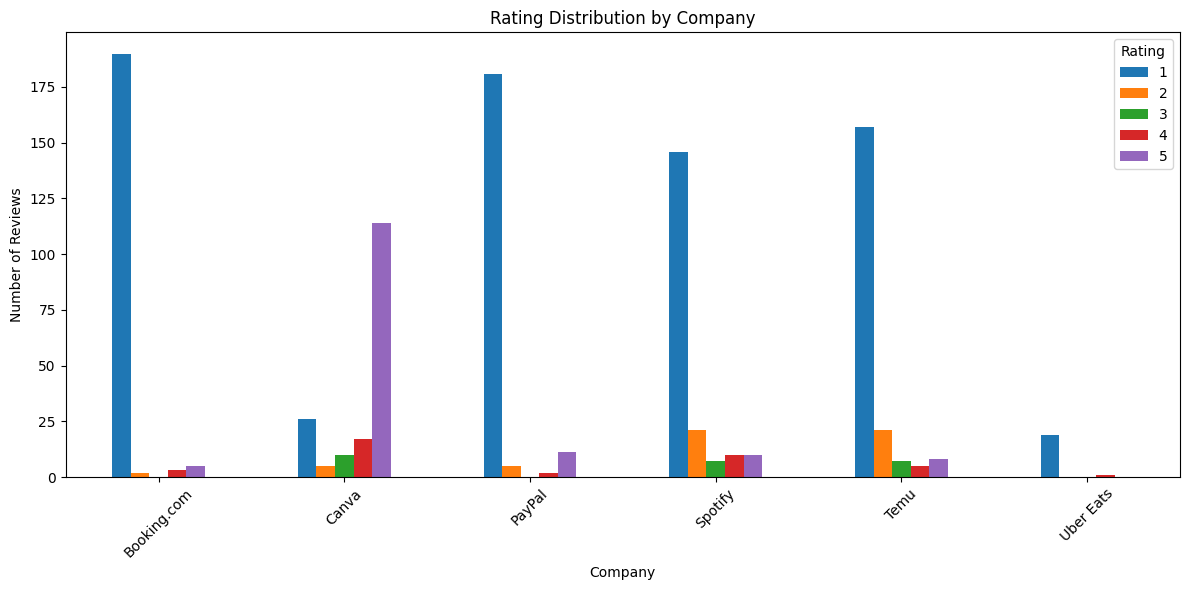

In [213]:
# ============================================================
# CHART 6 — RATING DISTRIBUTION BY COMPANY
# ============================================================

rating_company = pd.crosstab(
    clean_df["Company"],
    clean_df["Rating"]
)

rating_company = rating_company.reindex(
    columns=[1, 2, 3, 4, 5],
    fill_value=0
)

print("\nRating Distribution by Company:")
print(rating_company)

rating_company.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Rating Distribution by Company")
plt.xlabel("Company")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Rating")

plt.tight_layout()
plt.show()



**7 → Reviews by Company**


Review Count by Company:
Company
Uber Eats       20
Canva          172
Spotify        194
Temu           198
PayPal         199
Booking.com    200
Name: count, dtype: int64


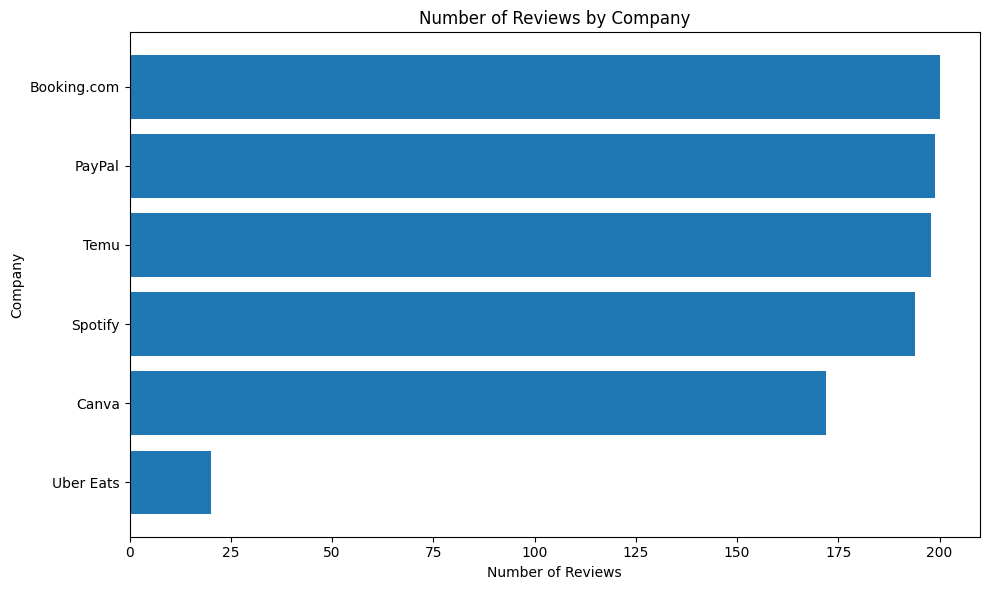

In [214]:
# ============================================================
# CHART 7 — REVIEW COUNT BY COMPANY
# ============================================================

company_counts = clean_df["Company"].value_counts().sort_values(
    ascending=True
)

print("\nReview Count by Company:")
print(company_counts)

plt.figure(figsize=(10, 6))

plt.barh(
    company_counts.index,
    company_counts.values
)

plt.title("Number of Reviews by Company")
plt.xlabel("Number of Reviews")
plt.ylabel("Company")

plt.tight_layout()
plt.show()


8 → Review Length


Review Length Statistics:
       Word_Count  Character_Count
count  983.000000       983.000000
mean    47.743642       330.016277
std     52.480521       382.262987
min      1.000000         4.000000
25%     16.000000       104.000000
50%     32.000000       217.000000
75%     59.000000       396.000000
max    451.000000      3536.000000


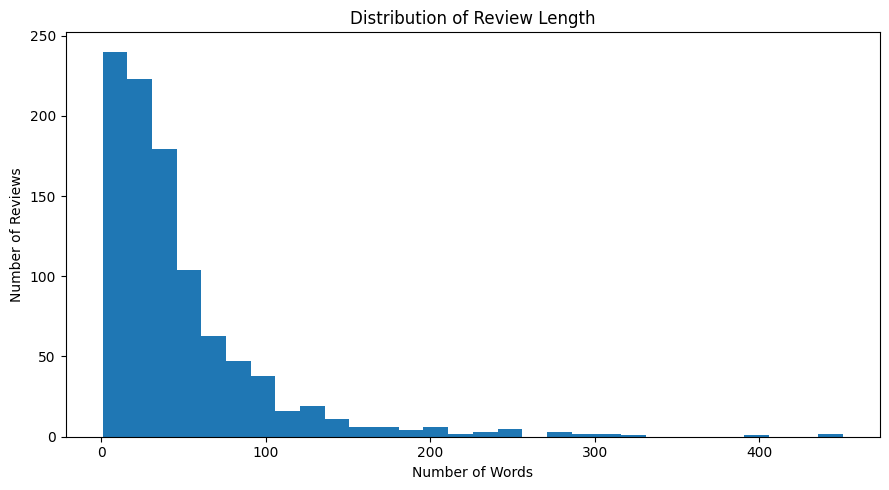

In [215]:
# ============================================================
# CHART 8 — REVIEW LENGTH DISTRIBUTION
# ============================================================

# Create word count if it doesn't already exist
if "Word_Count" not in clean_df.columns:
    clean_df["Word_Count"] = (
        clean_df["Review Text"]
        .fillna("")
        .astype(str)
        .str.split()
        .str.len()
    )

if "Character_Count" not in clean_df.columns:
    clean_df["Character_Count"] = (
        clean_df["Review Text"]
        .fillna("")
        .astype(str)
        .str.len()
    )

print("\nReview Length Statistics:")
print(
    clean_df[["Word_Count", "Character_Count"]]
    .describe()
)

plt.figure(figsize=(9, 5))

plt.hist(
    clean_df["Word_Count"],
    bins=30
)

plt.title("Distribution of Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()



**9 → Top Words**

Top 20 Most Frequent Words:


,Word,Frequency
0,not,801
1,booking,631
2,no,476
3,paypal,438
4,com,437
5,customer,382
6,service,356
7,money,317
8,refund,315
9,account,298


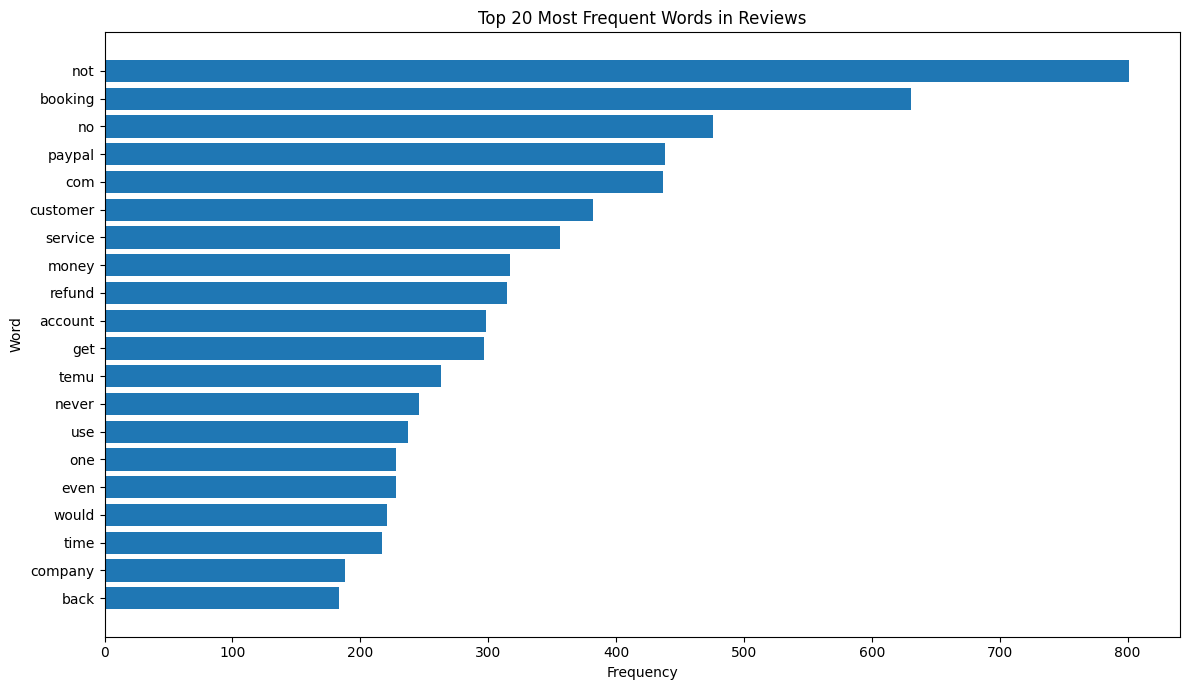

In [225]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Combine all cleaned reviews
all_text = " ".join(
    clean_df["Clean_Text"]
    .fillna("")
    .astype(str)
)

# Count words
word_counts = Counter(all_text.split())

# Top 20 words
top_words = word_counts.most_common(20)

top_words_df = pd.DataFrame(
    top_words,
    columns=["Word", "Frequency"]
)

print("Top 20 Most Frequent Words:")
display(top_words_df)

# Chart
plt.figure(figsize=(12, 7))

plt.barh(
    top_words_df["Word"][::-1],
    top_words_df["Frequency"][::-1]
)

plt.title("Top 20 Most Frequent Words in Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

**10 → Positive Words**

Top 20 Positive Words:


,Word,Frequency
0,canva,77
1,use,46
2,great,36
3,easy,35
4,not,33
5,really,32
6,like,27
7,customer,25
8,time,24
9,service,23


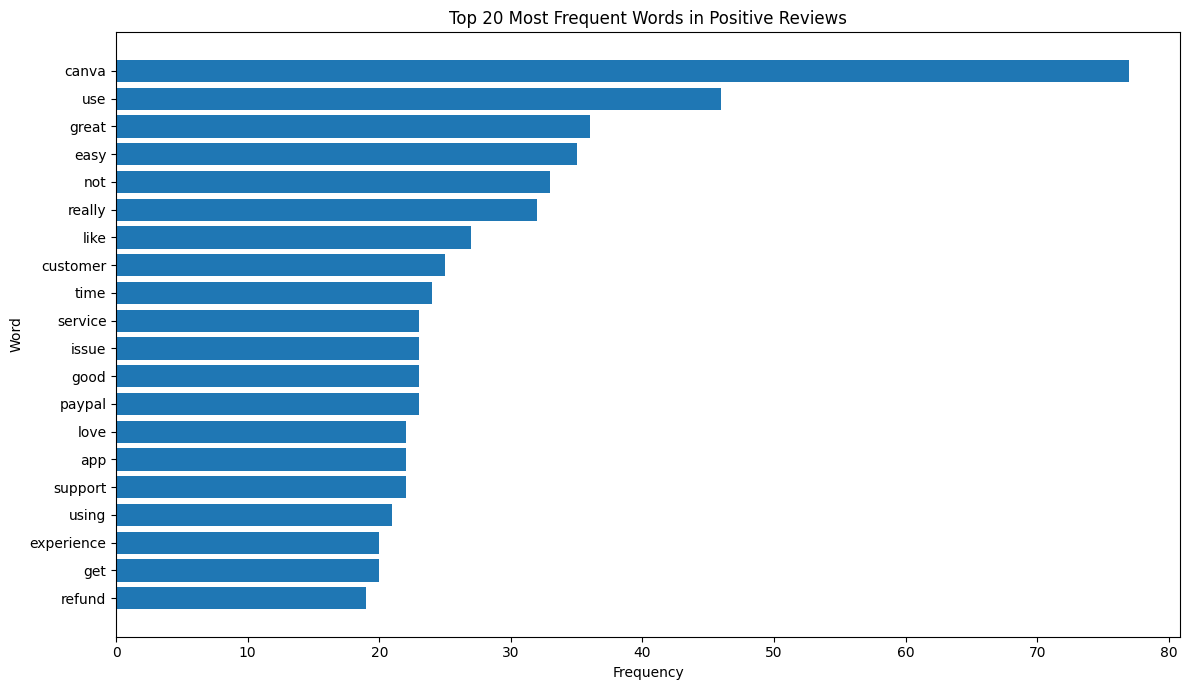

In [226]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Positive reviews
positive_reviews = clean_df[
    clean_df["Sentiment"] == "Positive"
].copy()

# Combine text
positive_text = " ".join(
    positive_reviews["Clean_Text"]
    .fillna("")
    .astype(str)
)

# Count words
positive_word_counts = Counter(positive_text.split())

# Top 20
top_positive = positive_word_counts.most_common(20)

positive_words_df = pd.DataFrame(
    top_positive,
    columns=["Word", "Frequency"]
)

print("Top 20 Positive Words:")
display(positive_words_df)

# Chart
plt.figure(figsize=(12, 7))

plt.barh(
    positive_words_df["Word"][::-1],
    positive_words_df["Frequency"][::-1]
)

plt.title("Top 20 Most Frequent Words in Positive Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

**11 → Negative Words**

Top 20 Negative Words:


,Word,Frequency
0,not,756
1,booking,622
2,no,460
3,com,431
4,paypal,415
5,customer,357
6,service,332
7,money,311
8,refund,295
9,account,286


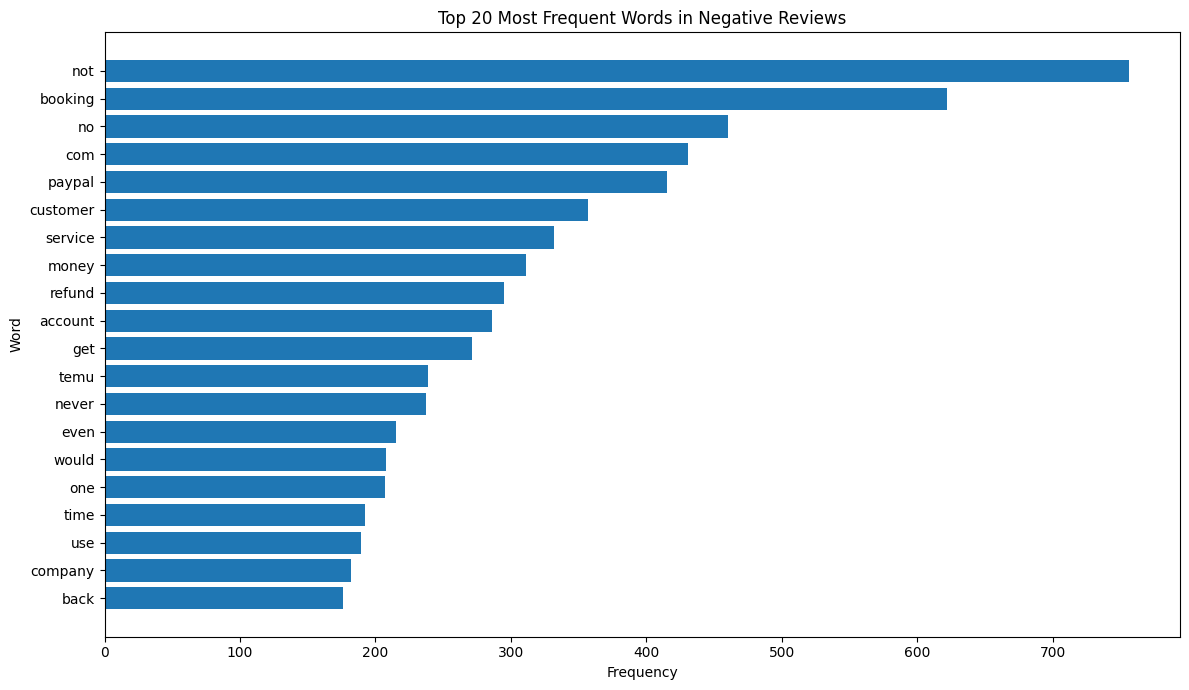

In [227]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Negative reviews
negative_reviews = clean_df[
    clean_df["Sentiment"] == "Negative"
].copy()

# Combine text
negative_text = " ".join(
    negative_reviews["Clean_Text"]
    .fillna("")
    .astype(str)
)

# Count words
negative_word_counts = Counter(negative_text.split())

# Top 20
top_negative = negative_word_counts.most_common(20)

negative_words_df = pd.DataFrame(
    top_negative,
    columns=["Word", "Frequency"]
)

print("Top 20 Negative Words:")
display(negative_words_df)

# Chart
plt.figure(figsize=(12, 7))

plt.barh(
    negative_words_df["Word"][::-1],
    negative_words_df["Frequency"][::-1]
)

plt.title("Top 20 Most Frequent Words in Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

**12 → Model Comparison**

Model Comparison:


,Model,Accuracy,Macro F1
0,Logistic Regression,0.9036,0.5732
1,Multinomial Naive Bayes,0.8223,0.4056
2,Linear SVM,0.8934,0.5534
3,Random Forest,0.8934,0.5536
4,Logistic Regression + Oversampling,0.9036,0.5699
5,Logistic Regression (C=2),0.9137,0.5845


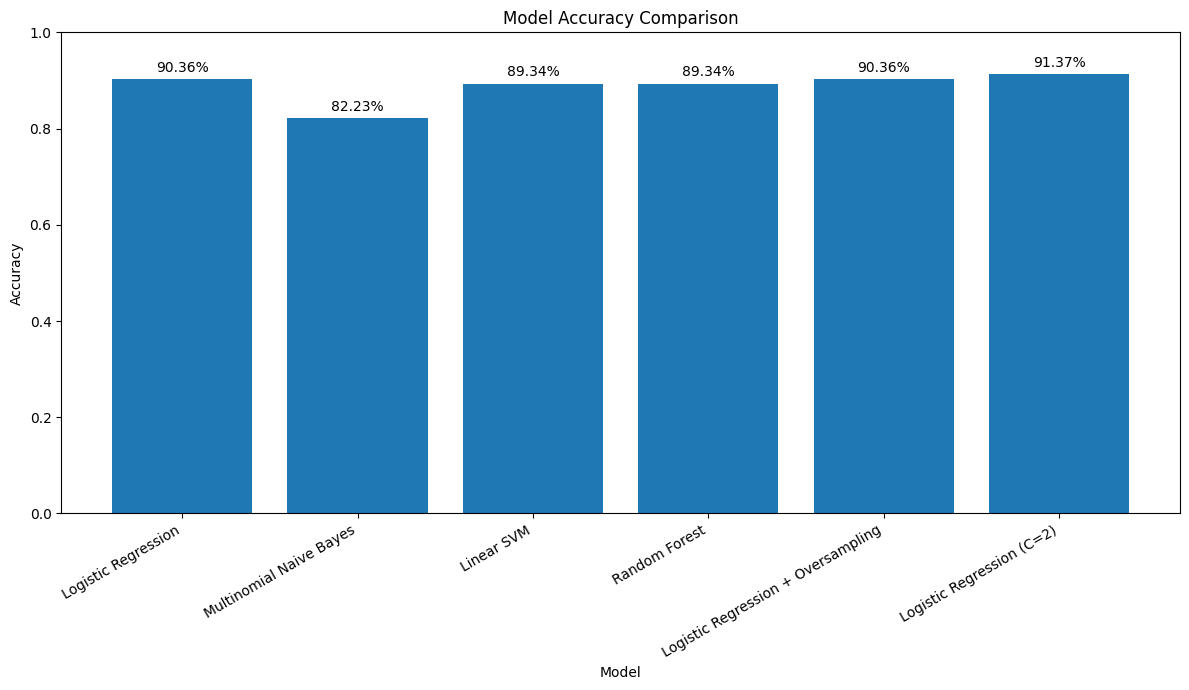

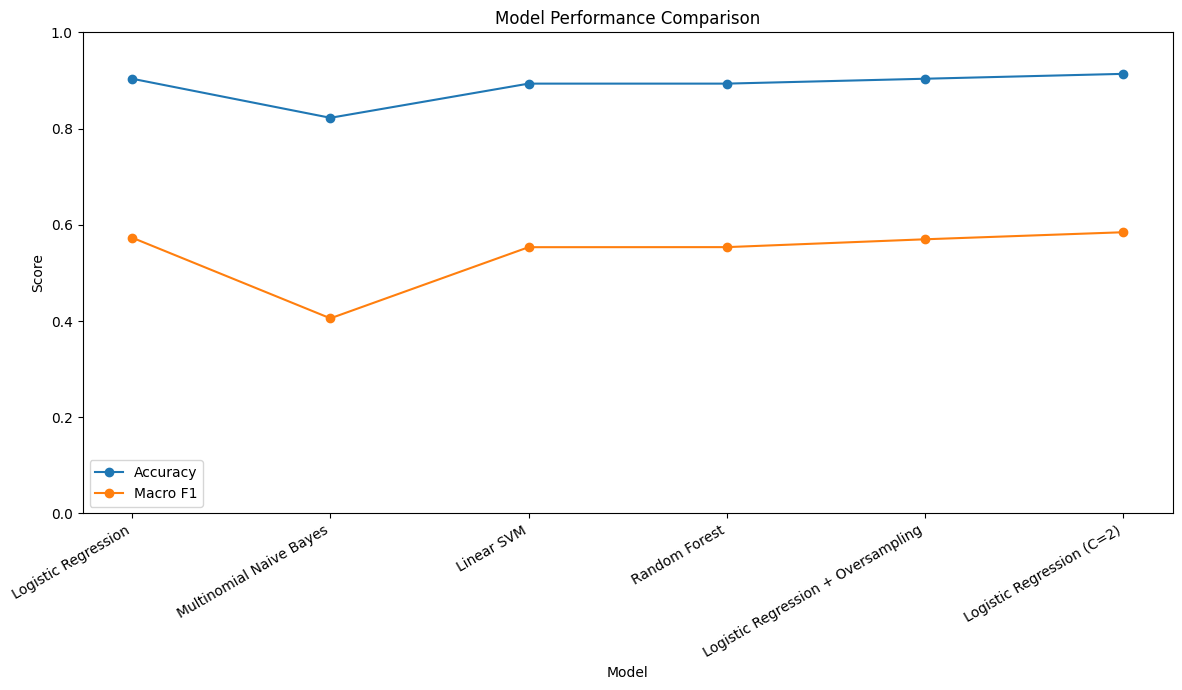

In [230]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# MODEL COMPARISON DATA
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM",
        "Random Forest",
        "Logistic Regression + Oversampling",
        "Logistic Regression (C=2)"
    ],

    "Accuracy": [
        0.903553,
        0.822335,
        0.893401,
        0.893401,
        0.903553,
        0.913706
    ],

    "Macro F1": [
        0.573180,
        0.405578,
        0.553445,
        0.553565,
        0.569866,
        0.584520
    ]
})

# Display results
print("Model Comparison:")
display(model_comparison.round(4))


# ============================================================
# CHART 12A — ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

bars = plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.xticks(
    rotation=30,
    ha="right"
)

# Add accuracy values on bars
for bar, value in zip(bars, model_comparison["Accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.2%}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ============================================================
# CHART 12B — ACCURACY vs MACRO F1
# ============================================================

plt.figure(figsize=(12, 7))

x = range(len(model_comparison))

plt.plot(
    x,
    model_comparison["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    x,
    model_comparison["Macro F1"],
    marker="o",
    label="Macro F1"
)

plt.xticks(
    x,
    model_comparison["Model"],
    rotation=30,
    ha="right"
)

plt.ylim(0, 1)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")

plt.legend()

plt.tight_layout()
plt.show()

**Final Summary**

In [231]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("CHART GENERATION COMPLETE")
print("=" * 60)

print("""
Chart 5  → Overall Rating Distribution
Chart 6  → Rating Distribution by Company
Chart 7  → Review Count by Company
Chart 8  → Review Length Distribution
Chart 9  → Top 20 Most Frequent Words
Chart 10 → Top 20 Positive Words
Chart 11 → Top 20 Negative Words
Chart 12 → Model Performance Comparison
""")

print("Total charts completed: 12")


CHART GENERATION COMPLETE

Chart 5  → Overall Rating Distribution
Chart 6  → Rating Distribution by Company
Chart 7  → Review Count by Company
Chart 8  → Review Length Distribution
Chart 9  → Top 20 Most Frequent Words
Chart 10 → Top 20 Positive Words
Chart 11 → Top 20 Negative Words
Chart 12 → Model Performance Comparison

Total charts completed: 12


In [232]:
print("Available models:")

for name, obj in globals().copy().items():
    if hasattr(obj, "predict") and hasattr(obj, "fit"):
        print(name, "->", type(obj).__name__)

Available models:
LogisticRegression -> type
lr_model -> LogisticRegression
MultinomialNB -> ABCMeta
nb_model -> MultinomialNB
LinearSVC -> type
svm_model -> LinearSVC
RandomForestClassifier -> ABCMeta
rf_model -> RandomForestClassifier
lr_balanced -> LogisticRegression
model -> LogisticRegression
final_model -> LogisticRegression


In [233]:
import joblib
import os
import shutil

# Create folder
save_dir = "/content/saved_models"
os.makedirs(save_dir, exist_ok=True)

# ==============================
# SAVE TF-IDF VECTORIZER
# ==============================

joblib.dump(
    tfidf,
    f"{save_dir}/tfidf_vectorizer.pkl"
)

# ==============================
# SAVE ALL MODELS
# ==============================

joblib.dump(
    lr_model,
    f"{save_dir}/logistic_regression.pkl"
)

joblib.dump(
    nb_model,
    f"{save_dir}/naive_bayes.pkl"
)

joblib.dump(
    svm_model,
    f"{save_dir}/linear_svm.pkl"
)

joblib.dump(
    rf_model,
    f"{save_dir}/random_forest.pkl"
)

joblib.dump(
    lr_balanced,
    f"{save_dir}/logistic_regression_balanced.pkl"
)

joblib.dump(
    final_model,
    f"{save_dir}/logistic_regression_C2_FINAL.pkl"
)

print("✅ All models saved successfully!\n")

# Show saved files
for file in os.listdir(save_dir):
    path = os.path.join(save_dir, file)
    size = os.path.getsize(path) / (1024 * 1024)
    print(f"{file:<45} {size:.2f} MB")

✅ All models saved successfully!

logistic_regression_balanced.pkl              0.12 MB
logistic_regression_C2_FINAL.pkl              0.12 MB
tfidf_vectorizer.pkl                          0.19 MB
random_forest.pkl                             9.54 MB
naive_bayes.pkl                               0.23 MB
linear_svm.pkl                                0.12 MB
logistic_regression.pkl                       0.12 MB


In [234]:
import shutil
import os

zip_path = shutil.make_archive(
    "/content/sentiment_models",
    "zip",
    "/content/saved_models"
)

print("✅ ZIP created successfully:")
print(zip_path)

print("\nZIP contents:")

import zipfile

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    for file in zip_ref.namelist():
        print(" -", file)

✅ ZIP created successfully:
/content/sentiment_models.zip

ZIP contents:
 - logistic_regression_balanced.pkl
 - logistic_regression_C2_FINAL.pkl
 - tfidf_vectorizer.pkl
 - random_forest.pkl
 - naive_bayes.pkl
 - linear_svm.pkl
 - logistic_regression.pkl


In [235]:
from google.colab import files

files.download("/content/sentiment_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [236]:
# Save final dataset as CSV
clean_df.to_csv("/content/final_sentiment_dataset.csv", index=False)

print("Dataset saved successfully!")
print("Shape:", clean_df.shape)

Dataset saved successfully!
Shape: (983, 14)


In [237]:
from google.colab import files

files.download("/content/final_sentiment_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [238]:
df.to_csv("/content/original_scraped_dataset.csv", index=False)

from google.colab import files

files.download("/content/original_scraped_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>